# 03 - Pilot Analysis

Pull raw experiment results from HuggingFace (or local), run scoring (PII Codex–aligned), build charts, and upload final results. **Label alignment** (Section 3.2) is required for zero-shot and recommended whenever the model uses different label names.

**Prerequisite:** Notebook 2 has been run and raw results uploaded to the results repo (or available at `results/experiment_results.json`).

## 1. Setup

Repos, run type, and label mapping (for scoring).

In [1]:
import json
import os
import yaml
from pathlib import Path
from dotenv import load_dotenv
import pandas as pd
import numpy as np
from datasets import Dataset
from collections import defaultdict
from huggingface_hub import login, HfApi, hf_hub_download
from huggingface_hub import hf_hub_download as _dl

# Match notebook 2: run type and repos from repo root config.yaml (single source of truth)
RUN_TYPE = "pilot"  # "pilot" to load pilot results | "main" to load main results
_repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPO_ROOT = _repo_root
_config_yaml = REPO_ROOT / "config.yaml"
if _config_yaml.exists():
    with open(_config_yaml) as f:
        _config = yaml.safe_load(f)
    BENCHMARK_REPO = _config["compiled_dataset"]["repo_id"]
    CONFIG_REPO = _config["config_repo"]["repo_id"]
    RESULTS_REPO = _config["results_repo"]["repo_id"]
    prompt_version = _config.get("experiment", {}).get("prompt_version", "v1")
else:
    BENCHMARK_REPO = "EdyVision/pii-skills-ablation"
    CONFIG_REPO = "EdyVision/pii-skills-ablation"
    RESULTS_REPO = "EdyVision/pii-skills-ablation-results"
    prompt_version = "v1"

# Load .env from project root
_env_path = REPO_ROOT / ".env"
if _env_path.exists():
    load_dotenv(_env_path)
    print("Loaded .env from", _env_path)
else:
    load_dotenv()
    print("No .env at repo root, using cwd or system env vars")
if os.getenv("HF_TOKEN"):
    login(token=os.getenv("HF_TOKEN"), add_to_git_credential=False)
    print("Logged in to Hugging Face")
else:
    print(
        "HF_TOKEN not set — private repos may return 404. Set HF_TOKEN in .env or environment."
    )

# Label mapping for scoring (local config first, else from HF config repo)
try:
    _mapping_local = REPO_ROOT / "config" / "pii_label_to_piicodex.json"
    if _mapping_local.exists():
        with open(_mapping_local) as _f:
            GROUND_TRUTH_TO_PIICODEX = json.load(_f)
        print(
            f"Loaded pii_label_to_piicodex.json from {_mapping_local} ({len(GROUND_TRUTH_TO_PIICODEX)} entries)"
        )
    else:
        _mapping_path = _dl(
            repo_id=CONFIG_REPO,
            filename="config/pii_label_to_piicodex.json",
            repo_type="dataset",
        )
        with open(_mapping_path) as _f:
            GROUND_TRUTH_TO_PIICODEX = json.load(_f)
        print(
            f"Loaded pii_label_to_piicodex.json from HF ({len(GROUND_TRUTH_TO_PIICODEX)} entries)"
        )
except Exception as e:
    print(f"Warning: could not load mapping: {e}")
    GROUND_TRUTH_TO_PIICODEX = {}

print(f"RUN_TYPE={RUN_TYPE}, prompt_version={prompt_version}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loaded .env from /Users/erosado/work/pii-codex-skills-ablation-study/.env
Logged in to Hugging Face
Loaded pii_label_to_piicodex.json from /Users/erosado/work/pii-codex-skills-ablation-study/config/pii_label_to_piicodex.json (136 entries)
RUN_TYPE=pilot, prompt_version=v1


## 2. Load raw results

Load from (1) HuggingFace results dataset split `{RUN_TYPE}_{prompt_version}` (what notebook 2 pushes), (2) local `results/experiment_results.json` at repo root, or (3) legacy HF file `{RUN_TYPE}/experiment_results.json`.

In [2]:
# 1) Try HuggingFace results dataset split (what notebook 2 pushes after each condition)
all_results = None
try:
    from datasets import load_dataset as _load_ds

    split_name = f"{RUN_TYPE}_{prompt_version}"
    results_ds = _load_ds(RESULTS_REPO, split=split_name)
    benchmark_ds = _load_ds(BENCHMARK_REPO, split="test")
    # Index benchmark by id for ground_truth lookup
    benchmark_by_id = {}
    for i in range(len(benchmark_ds)):
        row = benchmark_ds[i]
        sid = row.get("id") or i
        benchmark_by_id[sid] = row
    # Build all_results with ground_truth from benchmark (prefer pii_codex_ground_truth for consistent scoring)
    all_results = []
    for row in results_ds:
        sid = row["sample_id"]
        bench_row = benchmark_by_id.get(sid, {})
        gt_raw = []
        pii_codex_types = (
            None  # list of PII Codex type-name strings (same as notebook 01)
        )
        pii_codex_gt = bench_row.get("pii_codex_ground_truth")
        if pii_codex_gt is not None:
            if isinstance(pii_codex_gt, str):
                try:
                    parsed = json.loads(pii_codex_gt)
                except (json.JSONDecodeError, TypeError):
                    parsed = []
            else:
                parsed = pii_codex_gt if isinstance(pii_codex_gt, list) else []
            if parsed and isinstance(parsed[0], str):
                gt_raw = [{"type": t} for t in parsed]
                pii_codex_types = parsed
            elif parsed and isinstance(parsed[0], dict):
                gt_raw = parsed
        if not gt_raw and bench_row.get("ground_truth"):
            gt_raw = bench_row.get("ground_truth")
            if isinstance(gt_raw, str):
                try:
                    gt_raw = json.loads(gt_raw)
                except (json.JSONDecodeError, TypeError):
                    gt_raw = []
            if not isinstance(gt_raw, list):
                gt_raw = []
        preds = row.get("predictions")
        if isinstance(preds, str):
            try:
                preds = json.loads(preds)
            except (json.JSONDecodeError, TypeError):
                preds = []
        scores = row.get("scores")
        if isinstance(scores, str) and scores:
            try:
                scores = json.loads(scores)
            except (json.JSONDecodeError, TypeError):
                scores = None
        all_results.append(
            {
                "sample_id": sid,
                "source": row.get("source", ""),
                "model": row["model"],
                "condition": row["condition"],
                "predictions": preds or [],
                "ground_truth": gt_raw if isinstance(gt_raw, list) else [],
                "pii_codex_types": pii_codex_types,
                "scores": scores,
                "error": row.get("error"),
                "tool_executed": bool(row.get("tool_executed", False)),
                "skill_viewed": bool(row.get("skill_viewed", False)),
                "elapsed_seconds": row.get("elapsed_seconds"),
                "conversation_turns": row.get("conversation_turns"),
            }
        )
    print(f"Loaded {len(all_results)} results from HuggingFace (split={split_name})")
except Exception as e:
    print(f"Could not load from HF dataset split: {e}")

# 2) Fallback: local results/experiment_results.json (repo root)
local_path = REPO_ROOT / "results" / "experiment_results.json"
if all_results is None and local_path.exists():
    with open(local_path) as f:
        all_results = json.load(f)
    print(f"Loaded {len(all_results)} results from local {local_path}")

# 3) Fallback: HF file (legacy; notebook 2 no longer uploads this file)
if all_results is None:
    try:
        hf_path = hf_hub_download(
            repo_id=RESULTS_REPO,
            filename=f"{RUN_TYPE}/experiment_results.json",
            repo_type="dataset",
        )
        with open(hf_path) as f:
            all_results = json.load(f)
        print(
            f"Loaded {len(all_results)} results from HuggingFace ({RUN_TYPE}/experiment_results.json)"
        )
    except Exception as e:
        print(f"Could not load from HF file: {e}")

if all_results is None:
    raise SystemExit(
        "No results. Run notebook 2 (results are pushed to the HF dataset split), or place experiment_results.json in results/."
    )

# Diagnostic: rows with no ground_truth (may need human-in-the-loop labeling)
missing_gt = [r for r in all_results if not (r.get("ground_truth"))]
n_missing = len(missing_gt)
if n_missing > 0:
    print(
        f"\nLabels missing: {n_missing} rows have no ground_truth (candidates for human-in-the-loop)."
    )
    # Unique sample_ids affected (each sample can appear in multiple model/condition rows)
    sample_ids_missing = sorted(set(r["sample_id"] for r in missing_gt))
    print(f"  Unique sample_ids without labels: {len(sample_ids_missing)}")
    if len(sample_ids_missing) <= 20:
        print(f"  sample_ids: {sample_ids_missing}")
    else:
        print(f"  sample_ids (first 20): {sample_ids_missing[:20]} ...")
else:
    print("\nLabels: all rows have ground_truth.")

Loaded 3200 results from HuggingFace (split=pilot_v1)

Labels: all rows have ground_truth.


### 2.1 Benchmark dataset overview

The benchmark used for this ablation is built from multiple PII sources. Below we show sample counts and PII density by source, plus PII type coverage, so the analyses that follow are grounded in the same data.

In [3]:
# One row per sample (deduplicate by sample_id; source and ground_truth are same across model/condition)
_seen = set()
benchmark_samples = []
for r in all_results:
    sid = r.get("sample_id")
    if sid is None or sid in _seen:
        continue
    _seen.add(sid)
    gt = r.get("ground_truth") or []
    if not isinstance(gt, list):
        gt = []
    benchmark_samples.append(
        {
            "sample_id": sid,
            "source": r.get("source", ""),
            "ground_truth": gt,
            "pii_codex_types": r.get("pii_codex_types"),
        }
    )

# Per-sample stats for charts
benchmark_sample_stats = [
    {"source": s["source"], "n_pii": len(s["ground_truth"])} for s in benchmark_samples
]
df_benchmark_sample_stats = pd.DataFrame(benchmark_sample_stats)

# Summary by source (the one dataframe for the story)
df_benchmark_summary = (
    df_benchmark_sample_stats.groupby("source")
    .agg(
        n_samples=("n_pii", "count"),
        total_pii=("n_pii", "sum"),
        mean_pii_per_sample=("n_pii", "mean"),
    )
    .reset_index()
)
df_benchmark_summary["mean_pii_per_sample"] = df_benchmark_summary[
    "mean_pii_per_sample"
].round(2)

# PII type counts by source (for PII Type Coverage chart; same logic as notebook 01)
type_by_source = defaultdict(lambda: defaultdict(int))
for s in benchmark_samples:
    src = s["source"]
    types_list = s.get("pii_codex_types")
    if types_list is not None:
        for t in types_list:
            type_by_source[src][t] += 1
    else:
        for t in s["ground_truth"]:
            pii_type = t.get("type", "UNKNOWN") if isinstance(t, dict) else str(t)
            type_by_source[src][pii_type] += 1

df_benchmark_summary

,source,n_samples,total_pii,mean_pii_per_sample
0,ai4privacy,174,1072,6.16
1,gretel_pii_masking,16,69,4.31
2,nvidia_nemotron_pii,10,50,5.00


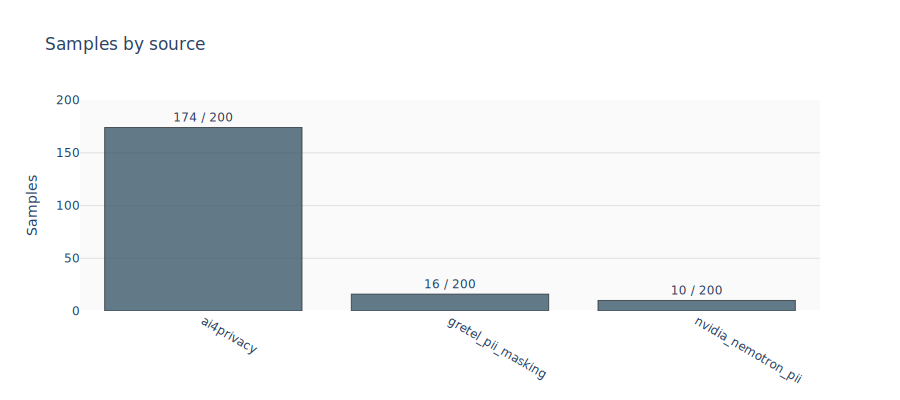

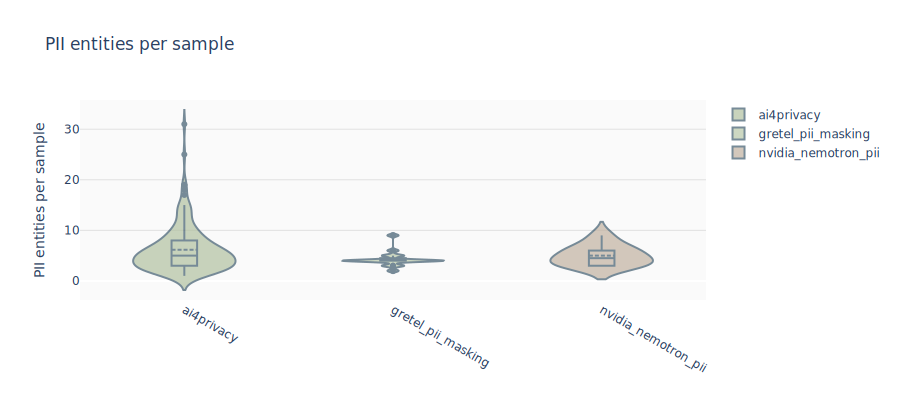

In [4]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Palette for benchmark overview (matches notebook 1 style)
EXTENDED_COLORS = [
    "#2D353B",
    "#4A5259",
    "#7A8A94",
    "#A8B5BC",
    "#1E3A47",
    "#3D5A6C",
    "#5A8799",
    "#8FB4C4",
    "#4A5A3A",
    "#8B9E6B",
    "#A8BC8A",
    "#C8DBAF",
]
LIGHT_EXTENDED_COLORS = [
    "#B8C0C8",
    "#A8B4BC",
    "#A0BCC8",
    "#98B4C0",
    "#B0C0A0",
    "#B8C8A8",
    "#C0B0A0",
    "#C8BCB0",
]

sources = df_benchmark_summary["source"].tolist()
sample_counts = df_benchmark_summary["n_samples"].tolist()
total_samples = sum(sample_counts)
max_samples = max(sample_counts)
y_top = max_samples * 1.15  # padding so top bar label is not cut off

# Samples by source (separate figure)
fig_samples = go.Figure(
    go.Bar(
        name="Samples",
        x=sources,
        y=sample_counts,
        marker_color=EXTENDED_COLORS[5],
        marker_line=dict(width=1, color="#2D353B"),
        marker_opacity=0.8,
        text=[f"{c:,} / {total_samples:,}" for c in sample_counts],
        textposition="outside",
    )
)
fig_samples.update_layout(
    title="Samples by source",
    plot_bgcolor="#fafafa",
    height=400,
    width=900,
    margin=dict(b=80),
    legend=dict(orientation="h", yanchor="top", y=-0.12, xanchor="center", x=0.5),
)
fig_samples.update_yaxes(title_text="Samples", gridcolor="#e0e0e0", range=[0, y_top])
fig_samples.update_xaxes(tickangle=30)
fig_samples.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))

# PII entities per sample (separate figure)
fig_violin = go.Figure()
for i, source in enumerate(sources):
    source_data = df_benchmark_sample_stats[
        df_benchmark_sample_stats["source"] == source
    ]
    fig_violin.add_trace(
        go.Violin(
            x=[source] * len(source_data),
            y=source_data["n_pii"],
            name=source,
            fillcolor=LIGHT_EXTENDED_COLORS[(i + 4) % len(LIGHT_EXTENDED_COLORS)],
            line_color=EXTENDED_COLORS[5],
            opacity=0.7,
            meanline_visible=True,
            box_visible=True,
        )
    )
fig_violin.update_layout(
    title="PII entities per sample",
    plot_bgcolor="#fafafa",
    height=400,
    width=900,
    margin=dict(b=100),
)
fig_violin.update_yaxes(title_text="PII entities per sample", gridcolor="#e0e0e0")
fig_violin.update_xaxes(tickangle=30)
fig_violin.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))

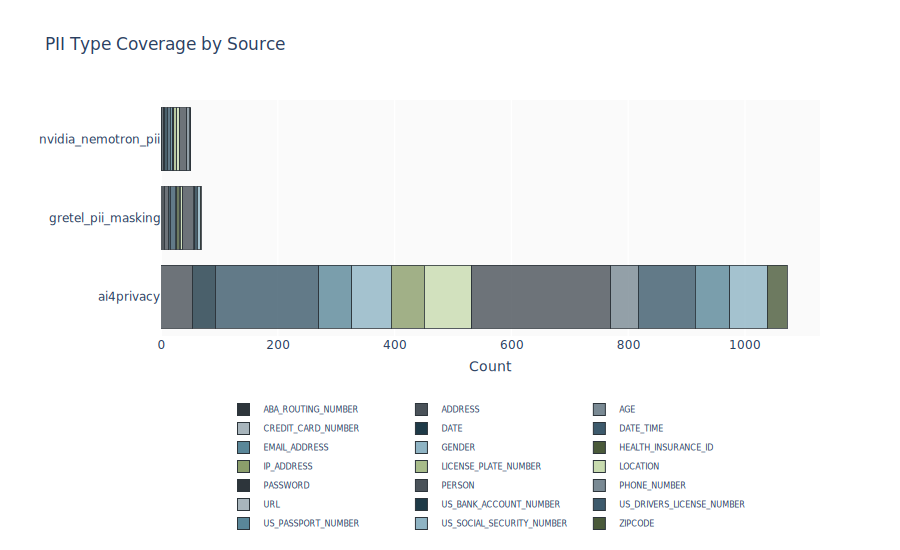

In [5]:
from collections import defaultdict

# PII type coverage (use this notebook's benchmark_samples; type_by_source built above is reused)
type_by_source = defaultdict(lambda: defaultdict(int))
for s in benchmark_samples:
    src = s["source"]
    types_list = s.get("pii_codex_types")
    if types_list is not None:
        for t in types_list:
            type_by_source[src][t] += 1
    else:
        for t in s["ground_truth"]:
            pii_type = t.get("type", "UNKNOWN") if isinstance(t, dict) else str(t)
            type_by_source[src][pii_type] += 1

sources = df_benchmark_summary["source"].tolist()
all_types = sorted(set(t for c in type_by_source.values() for t in c.keys()))

fig_type = go.Figure()
for i, pii_type in enumerate(all_types):
    counts = [type_by_source[src].get(pii_type, 0) for src in sources]
    fig_type.add_trace(
        go.Bar(
            name=pii_type,
            x=counts,
            y=sources,
            orientation="h",
            marker_color=EXTENDED_COLORS[i % len(EXTENDED_COLORS)],
            marker_line=dict(width=1, color="#2D353B"),
            marker_opacity=0.8,
        )
    )

fig_type.update_layout(
    barmode="stack",
    title="PII Type Coverage by Source",
    xaxis_title="Count",
    yaxis_title="",
    height=550,  # taller to fit legend
    width=900,
    plot_bgcolor="#fafafa",
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.25,  # push further down
        xanchor="center",
        x=0.5,
        font=dict(size=8),
        itemwidth=30,  # compact items
        traceorder="normal",
    ),
    margin=dict(l=140, b=180),  # more bottom margin
    xaxis=dict(title=dict(standoff=10)),  # keep axis label close to axis
)

fig_type.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))

## 3. Scoring

Compute precision, recall, and F1 by comparing predictions to ground truth (type + span IoU when available). **Zero-shot (and any condition where the model uses different label names) will score near zero until prediction labels are aligned to PII Codex** in Section 3.2 below.

In [6]:
def compute_span_iou(span1: dict, span2: dict) -> float:
    """Compute Intersection over Union for two spans."""
    start1, end1 = span1.get("start", 0), span1.get("end", 0)
    start2, end2 = span2.get("start", 0), span2.get("end", 0)

    intersection = max(0, min(end1, end2) - max(start1, start2))
    union = (end1 - start1) + (end2 - start2) - intersection

    return intersection / union if union > 0 else 0.0


# GROUND_TRUTH_TO_PIICODEX loaded from config repo (pii_label_to_piicodex.json) in Section 1.
def normalize_pii_type(pii_type: str) -> str:
    """Normalize prediction labels to PII-Codex PIIType.name for comparison with pii_codex_ground_truth."""
    if not pii_type:
        return "UNKNOWN"
    normalized = pii_type.upper().replace("-", "_").replace(" ", "_")
    out = GROUND_TRUTH_TO_PIICODEX.get(normalized, normalized)
    return out if out is not None else "UNKNOWN"


def compute_metrics(
    predictions: list, ground_truth: list, overlap_threshold: float = 0.5
) -> dict:
    """Compute precision, recall, F1 for PII detection."""
    # Filter valid predictions (must be dicts with "type" key)
    valid_preds = [p for p in predictions if isinstance(p, dict) and "type" in p]

    if not ground_truth:
        return {
            "precision": 1.0 if not valid_preds else 0.0,
            "recall": 1.0,
            "f1": 1.0 if not valid_preds else 0.0,
        }

    if not valid_preds:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    matched_truth = set()
    tp = 0

    for pred in valid_preds:
        pred_type = normalize_pii_type(pred.get("type", ""))

        for i, truth in enumerate(ground_truth):
            if i in matched_truth:
                continue

            truth_type = normalize_pii_type(truth.get("type", ""))
            if pred_type != truth_type:
                continue

            # Ground truth from benchmark often has type only (no start/end); treat as type-only match
            truth_has_span = truth.get("start", 0) != 0 or truth.get("end", 0) != 0
            if not truth_has_span:
                tp += 1
                matched_truth.add(i)
                break
            iou = compute_span_iou(pred, truth)
            if iou >= overlap_threshold:
                tp += 1
                matched_truth.add(i)
                break

    precision = tp / len(valid_preds) if valid_preds else 0
    recall = tp / len(ground_truth) if ground_truth else 0
    f1 = (
        2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    )

    return {
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
    }


# Score all results
for result in all_results:
    metrics = compute_metrics(result["predictions"], result["ground_truth"])
    result["scores"] = metrics

print("Scoring complete")

Scoring complete


### 3.2 Label alignment (required for zero-shot)

Scoring compares **prediction** types to **ground truth** (PII Codex). If the model outputs different label names (e.g. `PERSON_NAME`, `NAME`), they must be mapped to PII Codex. Run the **inspect** cell below to see which prediction labels are unmapped, then add a mapping and run the **re-score** cell.

In [7]:
# Collect every unique prediction type (raw) and whether it maps under GROUND_TRUTH_TO_PIICODEX
from collections import defaultdict

# Compact display so tables don't get cut off and columns aren't overly spaced
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", 40)


def _normalize_key(t: str) -> str:
    if not t:
        return ""
    return t.upper().replace("-", "_").replace(" ", "_")


# All ground truth labels in the benchmark (raw + normalized + mapped to PII Codex)
gt_type_rows = []
for result in all_results:
    for truth in result.get("ground_truth") or []:
        if not isinstance(truth, dict):
            continue
        raw = truth.get("type", "")
        norm = _normalize_key(raw)
        if not norm:
            mapped = "(empty)"
        elif norm not in GROUND_TRUTH_TO_PIICODEX:
            mapped = "(unmapped)"
        else:
            mapped = GROUND_TRUTH_TO_PIICODEX[norm]
            mapped = "null" if mapped is None else mapped
        gt_type_rows.append(
            {
                "gt_raw": raw or "(empty)",
                "gt_normalized": norm or "(empty)",
                "gt_mapped_to_piicodex": mapped,
            }
        )
if gt_type_rows:
    gt_df = pd.DataFrame(gt_type_rows)
    gt_summary = (
        gt_df.groupby(
            ["gt_raw", "gt_normalized", "gt_mapped_to_piicodex"], dropna=False
        )
        .size()
        .reset_index(name="count")
    )
    print("Ground truth labels in benchmark (raw, normalized, mapped to PII Codex):")
    display(gt_summary)

# All prediction types (model output) + in_map
pred_type_rows = []
for result in all_results:
    for pred in result.get("predictions") or []:
        if not isinstance(pred, dict):
            continue
        raw = pred.get("type", "")
        norm = _normalize_key(raw)
        in_map = norm in GROUND_TRUTH_TO_PIICODEX if norm else False
        pred_type_rows.append(
            {
                "raw": raw or "(empty)",
                "normalized": norm or "(empty)",
                "in_map": in_map,
                "model": result.get("model", ""),
                "condition": result.get("condition", ""),
            }
        )

if pred_type_rows:
    pred_df = pd.DataFrame(pred_type_rows)
    summary = (
        pred_df.groupby(["raw", "normalized", "in_map"], dropna=False)
        .agg(
            count=("raw", "count"),
            models=("model", lambda s: ", ".join(sorted(s.unique()))),
            conditions=("condition", lambda s: ", ".join(sorted(s.unique()))),
        )
        .reset_index()
    )
    unmapped = summary[~summary["in_map"]]
    print("\nPrediction labels (model output):")
    display(summary)
    if len(unmapped) > 0:
        print(
            "\nUnmapped prediction labels (add these to PREDICTION_TO_PIICODEX in the next cell):"
        )
        display(unmapped[["raw", "normalized", "count"]])

        # For each unmapped pred type, show co-occurring ground truth (PII Codex) types in same result row
        unmapped_norms = set(unmapped["normalized"])
        pred_to_gt_mapped = defaultdict(lambda: defaultdict(int))
        for result in all_results:
            gt_mapped_in_row = set()
            for truth in result.get("ground_truth") or []:
                if not isinstance(truth, dict):
                    continue
                norm = _normalize_key(truth.get("type", ""))
                mapped = GROUND_TRUTH_TO_PIICODEX.get(norm, norm)
                if mapped:
                    gt_mapped_in_row.add(mapped)
            for pred in result.get("predictions") or []:
                if not isinstance(pred, dict):
                    continue
                pnorm = _normalize_key(pred.get("type", ""))
                if pnorm in unmapped_norms:
                    for g in gt_mapped_in_row:
                        pred_to_gt_mapped[pnorm][g] += 1
        cooccur = []
        for pnorm in sorted(unmapped_norms):
            for g, cnt in sorted(pred_to_gt_mapped[pnorm].items(), key=lambda x: -x[1]):
                cooccur.append(
                    {
                        "prediction_normalized": pnorm,
                        "gt_piicodex_in_same_row": g,
                        "count": cnt,
                    }
                )
        if cooccur:
            print(
                "\nCo-occurrence (row-level): when the model used an unmapped "
                "prediction label, which PII Codex GT types appeared \nin the same "
                "sample/row. Each row can have multiple GT types and multiple "
                "predictions, so one prediction \noften co-occurs with several GT types; "
                "use the GT table above and PII Codex types to choose the right mapping."
            )
            display(pd.DataFrame(cooccur))
else:
    print("No prediction types found in all_results.")

Ground truth labels in benchmark (raw, normalized, mapped to PII Codex):


,gt_raw,gt_normalized,gt_mapped_to_piicodex,count
0,ABA_ROUTING_NUMBER,ABA_ROUTING_NUMBER,(unmapped),112
1,ADDRESS,ADDRESS,ADDRESS,1008
2,AGE,AGE,null,16
3,CREDIT_CARD_NUMBER,CREDIT_CARD_NUMBER,CREDIT_CARD_NUMBER,32
4,DATE,DATE,DATE,768
5,DATE_TIME,DATE_TIME,DATE_TIME,3024
6,EMAIL_ADDRESS,EMAIL_ADDRESS,EMAIL_ADDRESS,1008
7,GENDER,GENDER,null,1072
8,HEALTH_INSURANCE_ID,HEALTH_INSURANCE_ID,(unmapped),112
9,IP_ADDRESS,IP_ADDRESS,IP_ADDRESS,912



Prediction labels (model output):


,raw,normalized,in_map,count,models,conditions
0,ACCOUNT_NUMBER,ACCOUNT_NUMBER,True,5,"gemma2_9b, llama3_8b, mistral_7b",with_docs
1,ADDRESS,ADDRESS,True,445,"gemma2_9b, llama3_8b, mistral_7b, qw...","with_docs, with_skills, with_tools"
2,AGE,AGE,True,3,"llama3_8b, mistral_7b, qwen2_7b","with_docs, with_skills, with_tools"
3,AGE_RANGE,AGE_RANGE,False,1,mistral_7b,with_docs
4,AMOUNT,AMOUNT,False,1,llama3_8b,with_tools
...,...,...,...,...,...,...
390,time_of_day,TIME_OF_DAY,False,2,"llama3_8b, qwen2_7b",zero_shot
391,transaction time,TRANSACTION_TIME,False,1,llama3_8b,zero_shot
392,username,USERNAME,True,100,"gemma2_9b, llama3_8b, mistral_7b, qw...","with_skills, with_tools, zero_shot"
393,vehicle_identifier,VEHICLE_IDENTIFIER,True,1,qwen2_7b,zero_shot



Unmapped prediction labels (add these to PREDICTION_TO_PIICODEX in the next cell):


,raw,normalized,count
3,AGE_RANGE,AGE_RANGE,1
4,AMOUNT,AMOUNT,1
5,APPOINTMENT_TIME,APPOINTMENT_TIME,4
6,Account Holder,ACCOUNT_HOLDER,2
9,Additional Last Name,ADDITIONAL_LAST_NAME,2
...,...,...,...
388,time of birth,TIME_OF_BIRTH,4
389,time zone,TIME_ZONE,1
390,time_of_day,TIME_OF_DAY,2
391,transaction time,TRANSACTION_TIME,1



Co-occurrence (row-level): when the model used an unmapped prediction label, which PII Codex GT types appeared 
in the same sample/row. Each row can have multiple GT types and multiple predictions, so one prediction 
often co-occurs with several GT types; use the GT table above and PII Codex types to choose the right mapping.


,prediction_normalized,gt_piicodex_in_same_row,count
0,ACCOUNT_HOLDER,DATE,2
1,ACCOUNT_HOLDER,PERSON,2
2,ACCOUNT_HOLDER,ABA_ROUTING_NUMBER,2
3,ACCOUNT_HOLDER,US_BANK_ACCOUNT_NUMBER,2
4,ADDITIONAL_LAST_NAME,PERSON,2
...,...,...,...
729,ZIP_CODE,US_SOCIAL_SECURITY_NUMBER,5
730,ZIP_CODE,DATE_TIME,5
731,ZIP_CODE,DATE,5
732,ZIP_CODE,US_DRIVERS_LICENSE_NUMBER,5


Add mapping from **model prediction labels** (normalized key) to **PII Codex** type below, then run the re-score cell. Keys should match the `normalized` column from the inspect table (e.g. `PERSON_NAME` -> `PERSON`).

In [8]:
# Map prediction labels (normalized) to PII Codex. Merge with GROUND_TRUTH_TO_PIICODEX for scoring.
# Obvious mappings from PII Codex enum (pii_codex.models.common.PIIType) and config; add more below or in the review cell.
PREDICTION_TO_PIICODEX = {
    # Identity (model outputs canonical PII Codex type name)
    "US_BANK_ACCOUNT_NUMBER": "US_BANK_ACCOUNT_NUMBER",
    "US_DRIVERS_LICENSE_NUMBER": "US_DRIVERS_LICENSE_NUMBER",
    "US_INDIVIDUAL_TAXPAYER_IDENTIFICATION": "US_INDIVIDUAL_TAXPAYER_IDENTIFICATION",
    "NRP": "NRP",  # Nationality, religion, political (PII Codex PIIType)
    # Driver / license
    "DRIVER_LICENSE_NUMBER": "US_DRIVERS_LICENSE_NUMBER",
    "US_DRIVER_LICENSE": "US_DRIVERS_LICENSE_NUMBER",
    "DRIVER'S_LICENSE": "US_DRIVERS_LICENSE_NUMBER",
    # SSN
    "SOCIAL_SECURITY_NUMBER": "US_SOCIAL_SECURITY_NUMBER",
    # Postal / zip
    "POSTAL_CODE": "ZIPCODE",
    "US_POSTAL_CODE": "ZIPCODE",
    # Location (COUNTRY_OF_ORIGIN -> LOCATION per paper Appendix A.2)
    "COUNTRY_OF_ORIGIN": "LOCATION",
    # Person / account
    "ACCOUNT_USERNAME": "PERSON",
    "SIBLING_NAME": "PERSON",
    "INDIVIDUAL": "PERSON",
    # Medical / health IDs (PII Codex: HEALTH_INSURANCE_ID)
    "MRN": "HEALTH_INSURANCE_ID",
    "MRN_NUMBER": "HEALTH_INSURANCE_ID",
    "PATIENT_ID": "HEALTH_INSURANCE_ID",
    "PATIENTID": "HEALTH_INSURANCE_ID",
    # ID document
    "ID_CARD_NUMBER": "US_PASSPORT_NUMBER",
    # Biometric (PII Codex: FINGERPRINT)
    "BIOM_IDENTIFIER": "FINGERPRINT",
    # Time
    "TIME_OF_DAY": "DATE_TIME",
    "SESSION_TIME": "DATE_TIME",
}
# Add any labels from the "for review" cell below, then re-run this cell.

combined_label_map = {**GROUND_TRUTH_TO_PIICODEX, **PREDICTION_TO_PIICODEX}


def _normalize_with_map(pii_type: str, label_map: dict) -> str:
    """Normalize a label using the given map (for re-scoring with alignment)."""
    if not pii_type:
        return "UNKNOWN"
    normalized = pii_type.upper().replace("-", "_").replace(" ", "_")
    out = label_map.get(normalized, normalized)
    return out if out is not None else "UNKNOWN"


# Re-score using combined map: predictions and ground_truth both normalized via combined_label_map
for result in all_results:
    preds = result["predictions"] or []
    gt = result["ground_truth"] or []
    valid_preds = [p for p in preds if isinstance(p, dict) and "type" in p]

    if not gt:
        result["scores"] = {
            "precision": 1.0 if not valid_preds else 0.0,
            "recall": 1.0,
            "f1": 1.0 if not valid_preds else 0.0,
        }
        continue
    if not valid_preds:
        result["scores"] = {"precision": 0.0, "recall": 0.0, "f1": 0.0}
        continue

    matched_truth = set()
    tp = 0
    for pred in valid_preds:
        pred_type = _normalize_with_map(pred.get("type", ""), combined_label_map)
        for i, truth in enumerate(gt):
            if i in matched_truth:
                continue
            truth_type = _normalize_with_map(truth.get("type", ""), combined_label_map)
            if pred_type != truth_type:
                continue
            truth_has_span = truth.get("start", 0) != 0 or truth.get("end", 0) != 0
            if not truth_has_span:
                tp += 1
                matched_truth.add(i)
                break
            iou = compute_span_iou(pred, truth)
            if iou >= 0.5:
                tp += 1
                matched_truth.add(i)
                break

    precision = tp / len(valid_preds)
    recall = tp / len(gt)
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    result["scores"] = {
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
    }

print("Re-scoring with label alignment complete.")

Re-scoring with label alignment complete.


### Notes from HuggingFace (benchmark source datasets)

The benchmark is built from three HuggingFace datasets. Their documented entity types can help map review labels to PII Codex:

- **ai4privacy/pii-masking-300k**: [Dataset card](https://huggingface.co/datasets/ai4privacy/pii-masking-300k) — Labels in data: USERNAME, TIME, LASTNAME1/2, EMAIL, SOCIALNUMBER, DATE, IDCARD, COUNTRY, BUILDING, STREET, CITY, STATE, POSTCODE, PASS, PASSPORT, DRIVERLICENSE, TEL, BOD, etc. (No ATTRIBUTE_NAME, CLIENT_ID, PERSON_ID in the dataset; those may be model-output only.)
- **nvidia/Nemotron-PII**: [Dataset card](https://huggingface.co/datasets/nvidia/Nemotron-PII) — Uses snake_case: `first_name`, `last_name`, `date_of_birth`, `street_address`, `company_name`, `vehicle_identifier`, `customer_id`, `medical_record_number`, `certificate_license_number`, `religious_belief`, `political_view`, `sexuality`, `blood_type`, `education_level`, `employment_status`, `occupation`, etc. **Suggested:** `vehicle_identifier` -> LICENSE_PLATE_NUMBER; `customer_id` -> no direct PII Codex type (identifier only); `religious_belief` / `political_view` / `sexuality` -> NRP or SEXUAL_PREFERENCE; `certificate_license_number` -> MEDICAL_LICENSE; `medical_record_number` / `health_plan_beneficiary_number` -> HEALTH_INSURANCE_ID.
- **gretelai/gretel-pii-masking-en-v1**: [Dataset card](https://huggingface.co/datasets/gretelai/gretel-pii-masking-en-v1) — Entity types in `entities`: `name`, `first_name`, `last_name`, `date_of_birth`, `ssn`, `account_number`, `medical_record_number`, `customer_id`, `street_address`, `license_plate`, `vehicle_identifier`, `employee_id`, `unique_identifier`, `biometric_identifier`, `user_name`, `email`, `phone_number`, `date`, `time`, `date_time`, `coordinate`, `ipv4`, `ipv6`, `credit_card_number`, `address`, `country`. **Suggested:** `vehicle_identifier` -> LICENSE_PLATE_NUMBER; `customer_id` / `employee_id` -> no direct PII Codex; `biometric_identifier` -> FINGERPRINT; `unique_identifier` -> leave for review.

Labels like ATTRIBUTE_NAME, ATTRIBUTE_VALUE, COMMENTS, ROLE, TEXT, PII, PII_TYPE do not appear in these three datasets and are likely model- or schema-specific; map by context if needed.

In [9]:
# Suggested equivalences from HuggingFace dataset docs (merge into PREDICTION_TO_PIICODEX above if you agree)
SUGGESTED_FROM_HF = {
    "VEHICLE_ID": "LICENSE_PLATE_NUMBER",  # Nemotron/Gretel: vehicle_identifier
    "COUNTRY_OF_ORIGIN": "LOCATION",  # country/origin -> LOCATION
}
# CLIENT_ID, PERSON_ID, EMPLOYEE_ID, PARENT_ID, SIBLING_ID, INDIVIDUAL_ID: no direct PII Codex type in HF docs (identifier-only)
# ATTRIBUTE_NAME, ATTRIBUTE_VALUE, COMMENTS, ROLE, TEXT, PII, PII_TYPE: not in benchmark source datasets; map by context
print("Suggested from HF (add to PREDICTION_TO_PIICODEX if desired):")
for k, v in SUGGESTED_FROM_HF.items():
    print(f"  {k!r}: {v!r}")

Suggested from HF (add to PREDICTION_TO_PIICODEX if desired):
  'VEHICLE_ID': 'LICENSE_PLATE_NUMBER'
  'COUNTRY_OF_ORIGIN': 'LOCATION'


### Labels for your review

The following unmapped prediction labels were <em>not</em> auto-mapped (ambiguous or not clearly in PII Codex). Add any of them to `PREDICTION_TO_PIICODEX` in the cell above, then re-run the re-score cell. PII Codex types: run `from pii_codex.models.common import PIIType; [t.name for t in PIIType]` to list canonical types.

In [10]:
# Unmapped labels left for your review (add to PREDICTION_TO_PIICODEX above if you know the PII Codex type)
REVIEW_LABELS = [
    "ATTRIBUTE_NAME",
    "ATTRIBUTE_VALUE",
    "CLIENT_ID",
    "COUNTRY_OF_ORIGIN",
    "COMMENTS",
    "IDENTIFIABLE",
    "IDENTIFICATION_NUMBER",
    "ID_NUMBER",
    "INDIVIDUAL_ID",
    "MEDICALCONDITION",
    "NUMBER",
    "PARENT_ID",
    "PARTY",
    "PERSON_ID",
    "PERSONAL_IDENTIFIER",
    "PSYCHOLOGICAL_HISTORY",
    "PII",
    "PII_TYPE",
    "ROLE",
    "SIBLING_ID",
    "SUBSTANCEUSEDISORDERHISTORY",
    "TEXT",
    "TRAUMAHISTORY",
    "US_ID",
    "US_ID_NUMBER",
    "VEHICLE_ID",
    "IDENTIFIER",
    "ID",
]
# Optional: add to PREDICTION_TO_PIICODEX and re-run re-score, e.g.:
# PREDICTION_TO_PIICODEX["IDENTIFICATION_NUMBER"] = "US_PASSPORT_NUMBER"
# PREDICTION_TO_PIICODEX["COUNTRY_OF_ORIGIN"] = "LOCATION"
print("Labels for review:", len(REVIEW_LABELS))
for lab in sorted(REVIEW_LABELS):
    print(" ", lab)

Labels for review: 28
  ATTRIBUTE_NAME
  ATTRIBUTE_VALUE
  CLIENT_ID
  COMMENTS
  COUNTRY_OF_ORIGIN
  ID
  IDENTIFIABLE
  IDENTIFICATION_NUMBER
  IDENTIFIER
  ID_NUMBER
  INDIVIDUAL_ID
  MEDICALCONDITION
  NUMBER
  PARENT_ID
  PARTY
  PERSONAL_IDENTIFIER
  PERSON_ID
  PII
  PII_TYPE
  PSYCHOLOGICAL_HISTORY
  ROLE
  SIBLING_ID
  SUBSTANCEUSEDISORDERHISTORY
  TEXT
  TRAUMAHISTORY
  US_ID
  US_ID_NUMBER
  VEHICLE_ID


## 4. Results & Visualization

### 4.1 Aggregate Results

In [11]:
# Create results DataFrame (includes timing and tool_calls for exploratory plots)
def _pii_types_str(ground_truth):
    if not ground_truth:
        return ""
    types = set()
    for g in ground_truth:
        t = normalize_pii_type(g.get("type", ""))
        if t:
            types.add(t)
    return ", ".join(sorted(types))


df_results = pd.DataFrame(
    [
        {
            "model": r["model"],
            "condition": r["condition"],
            "source": r["source"],
            "sample_id": r["sample_id"],
            "precision": r["scores"]["precision"],
            "recall": r["scores"]["recall"],
            "f1": r["scores"]["f1"],
            "error": r["error"] is not None,
            "tool_calls": 1 if r.get("tool_executed") else 0,
            "skill_viewed": 1 if r.get("skill_viewed") else 0,
            "elapsed_seconds": r.get("elapsed_seconds") or 0,
            "time_elapsed": r.get("elapsed_seconds") or 0,
            "conversation_turns": (
                r.get("conversation_turns")
                if r.get("conversation_turns") is not None
                else 1
            ),
            "pii_types": _pii_types_str(r.get("ground_truth", [])),
        }
        for r in all_results
    ]
)

# Single model x condition summary (canonical; includes execution metrics)
summary = (
    df_results.groupby(["model", "condition"])
    .agg(
        n=("f1", "count"),
        mean_f1=("f1", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        errors=("error", "sum"),
        tool_calls=("tool_calls", "sum"),
        skill_viewed=("skill_viewed", "sum"),
        mean_elapsed_s=("elapsed_seconds", "mean"),
        mean_turns=("conversation_turns", "mean"),
        median_f1=("f1", "median"),
    )
    .round(4)
    .rename(
        columns={
            "mean_f1": "f1_mu",
            "mean_precision": "prec_mu",
            "mean_recall": "rec_mu",
            "mean_elapsed_s": "elapsed_mu",
            "mean_turns": "turns_mu",
            "median_f1": "f1_median",
        }
    )
)


summary = summary.reset_index()
display(summary)

,model,condition,n,f1_mu,prec_mu,rec_mu,errors,tool_calls,skill_viewed,elapsed_mu,turns_mu,f1_median
0,gemma2_9b,with_docs,200,0.5573,0.7100,0.4933,0,0,0,9.7525,1.000,0.5714
1,gemma2_9b,with_skills,200,0.3909,0.4539,0.3884,0,200,200,11.8109,4.000,0.4000
2,gemma2_9b,with_tools,200,0.3915,0.4553,0.3867,0,200,0,8.2222,2.000,0.4000
3,gemma2_9b,zero_shot,200,0.5295,0.6829,0.4657,0,0,0,7.6046,1.000,0.5714
4,llama3_8b,with_docs,200,0.4121,0.4464,0.4193,0,0,0,8.5561,1.000,0.4530
5,llama3_8b,with_skills,200,0.3838,0.4189,0.4092,0,200,200,15.7364,3.925,0.4000
6,llama3_8b,with_tools,200,0.4334,0.4667,0.4560,0,200,0,14.9116,2.000,0.4365
7,llama3_8b,zero_shot,200,0.5980,0.6200,0.6127,0,0,0,3.3517,1.000,0.6667
8,mistral_7b,with_docs,200,0.5029,0.6286,0.4455,0,0,0,4.9205,1.000,0.5000
9,mistral_7b,with_skills,200,0.4344,0.5340,0.4059,0,200,108,9.6285,2.020,0.4000


#### Per-item F1 distribution

Distribution of F1 per sample by model and condition (median and spread are in the summary table above).

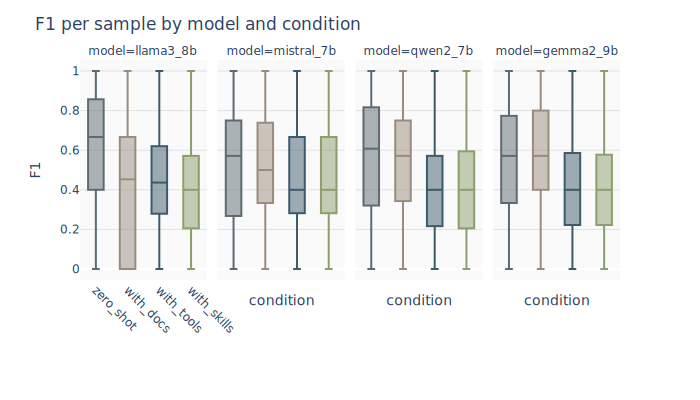

In [12]:
# Per-item F1: box by model x condition (palette matches CONDITION_COLORS elsewhere)
import plotly.express as px

condition_colors = {
    "zero_shot": "#5C6B73",
    "with_docs": "#9A8C7D",
    "with_tools": "#3D5A6C",
    "with_skills": "#8B9E6B",
}
condition_order = ["zero_shot", "with_docs", "with_tools", "with_skills"]
fig = px.box(
    df_results,
    x="condition",
    y="f1",
    color="condition",
    facet_col="model",
    color_discrete_map=condition_colors,
    category_orders={"condition": condition_order},
)
fig.update_layout(
    title="F1 per sample by model and condition",
    yaxis_title="F1",
    xaxis_title="",
    showlegend=False,
    height=400,
    plot_bgcolor="#fafafa",
    paper_bgcolor="white",
    margin=dict(b=120),
)
fig.update_xaxes(tickangle=45)
# Show condition labels only on first column (avoid repeating on every model facet)
n_cols = sum(1 for k in fig.layout if isinstance(k, str) and k.startswith("xaxis"))
for i in range(2, n_cols + 1):
    key = f"xaxis{i}"
    if key in fig.layout:
        fig.layout[key].showticklabels = False
fig.update_yaxes(showgrid=True, gridcolor="#e0e0e0")
# Match Per-Item F1 Improvement: same background on every facet (px uses default blue otherwise)
for attr in list(fig.layout):
    if attr.startswith("xaxis") and hasattr(fig.layout[attr], "plot_bgcolor"):
        fig.layout[attr].update(plot_bgcolor="#fafafa")
fig.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))

### 4.2 Condition comparisons, deltas, and recall by PII type

In [13]:
from scipy import stats as scipy_stats
from pathlib import Path
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Ensure results directory exists for saving figures (repo root so it works from notebooks/)
RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Color palette for all visuals
COLORS = [
    "#4A5259",  # dark slate
    "#5C6B73",  # slate gray
    "#9A8C7D",  # warm taupe
    "#3D5A6C",  # deep teal
    "#8B9E6B",  # muted sage
    "#B8C4A8",  # light sage
]

# Condition-specific (maps to your 4 conditions)
CONDITION_COLORS = {
    "zero_shot": "#5C6B73",  # slate gray
    "with_docs": "#9A8C7D",  # warm taupe
    "with_tools": "#3D5A6C",  # deep teal
    "with_skills": "#8B9E6B",  # muted sage
}
CONDITION_LABELS = {
    "zero_shot": "Zero-shot",
    "with_docs": "+Docs",
    "with_tools": "+Tool",
    "with_skills": "+Skills",
}

# Fixed order for delta/comparison charts so colors always match paper palette (no default red)
COMPARISON_ORDER = [
    "+Docs vs ZS",
    "+Tool vs ZS",
    "+Skills vs ZS",
    "+Tool vs +Docs",
    "+Skills vs +Docs",
    "+Skills vs +Tool",
]
COMPARISON_COLORS = {
    comp: COLORS[i % len(COLORS)] for i, comp in enumerate(COMPARISON_ORDER)
}


def bootstrap_ci(data, n_boot=1000, ci=0.95):
    """Compute bootstrap confidence interval for mean."""
    if len(data) < 2:
        return data.mean(), data.mean(), data.mean()
    boot_means = [
        np.random.choice(data, size=len(data), replace=True).mean()
        for _ in range(n_boot)
    ]
    lower = np.percentile(boot_means, (1 - ci) / 2 * 100)
    upper = np.percentile(boot_means, (1 + ci) / 2 * 100)
    return data.mean(), lower, upper


conditions = ["zero_shot", "with_docs", "with_tools", "with_skills"]
models = list(df_results["model"].unique())

#### Core Ablation Result

Performance by agent configuration with bootstrap 95% CI.

PII Detection Performance by Agent Configuration


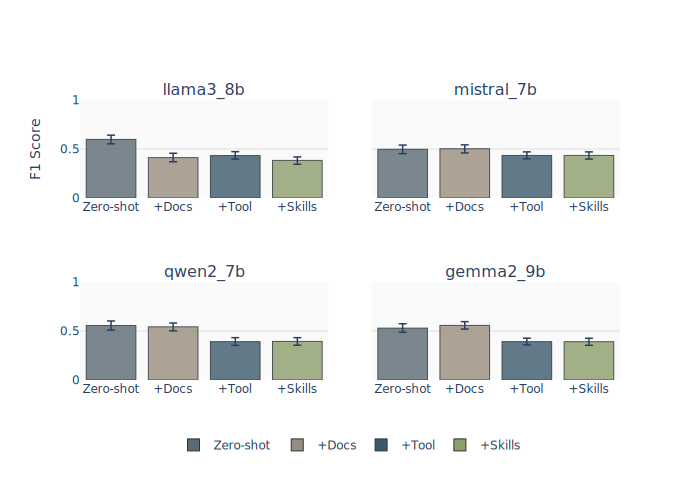

,model,ZS,+Docs,+Docs %,+Tool,+Tool %,+Skills,+Skills %
0,llama3_8b,0.598,0.412,-31.1%,0.433,-27.5%,0.384,-35.8%
1,mistral_7b,0.497,0.503,+1.1%,0.434,-12.7%,0.434,-12.7%
2,qwen2_7b,0.556,0.543,-2.4%,0.391,-29.6%,0.394,-29.1%
3,gemma2_9b,0.530,0.557,+5.2%,0.391,-26.1%,0.391,-26.2%


In [14]:
# Core Ablation Result (bars + bootstrap CI) - 2x2 by Model

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=models,
    shared_yaxes=True,
    vertical_spacing=0.30,
    horizontal_spacing=0.08,
)

for i, model in enumerate(models):
    r, c = i // 2 + 1, i % 2 + 1
    model_data = df_results[df_results["model"] == model]
    means, lowers, uppers = [], [], []

    for cond in conditions:
        cond_data = model_data[model_data["condition"] == cond]["f1"]
        mean, lower, upper = bootstrap_ci(cond_data.values)
        means.append(mean)
        lowers.append(mean - lower)
        uppers.append(upper - mean)

    for j, cond in enumerate(conditions):
        fig.add_trace(
            go.Bar(
                name=CONDITION_LABELS[cond],
                x=[CONDITION_LABELS[cond]],
                y=[means[j]],
                error_y=dict(
                    type="data",
                    symmetric=False,
                    array=[uppers[j]],
                    arrayminus=[lowers[j]],
                    thickness=1.5,
                    width=4,
                ),
                marker_color=CONDITION_COLORS[cond],
                marker_line=dict(width=1, color="#2D353B"),
                marker_opacity=0.8,
                showlegend=(i == 0),
                legendgroup=cond,
            ),
            row=r,
            col=c,
        )

fig.update_layout(
    title="",
    plot_bgcolor="#fafafa",
    legend=dict(orientation="h", yanchor="top", y=-0.18, xanchor="center", x=0.5),
    margin=dict(b=120),
    height=500,
    width=700,
    barmode="group",
)

for i in range(len(models)):
    r, c = i // 2 + 1, i % 2 + 1
    fig.update_yaxes(range=[0, 1], gridcolor="#e0e0e0", row=r, col=c)
fig.update_yaxes(title_text="F1 Score", row=1, col=1)

print("PII Detection Performance by Agent Configuration")
fig.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))
fig.write_image("fig_core_ablation_pilot.pdf")


# Improvement summary as DataFrame
imp_rows = []
for model in models:
    model_data = df_results[df_results["model"] == model]
    zs = model_data[model_data["condition"] == "zero_shot"]["f1"].mean()
    docs = model_data[model_data["condition"] == "with_docs"]["f1"].mean()
    tool = model_data[model_data["condition"] == "with_tools"]["f1"].mean()
    skills = model_data[model_data["condition"] == "with_skills"]["f1"].mean()
    imp_docs = ((docs - zs) / zs * 100) if zs > 0 else 0.0
    imp_tool = ((tool - zs) / zs * 100) if zs > 0 else 0.0
    imp_skills = ((skills - zs) / zs * 100) if zs > 0 else 0.0
    imp_rows.append(
        {
            "model": model,
            "ZS": zs,
            "+Docs": docs,
            "+Docs %": imp_docs,
            "+Tool": tool,
            "+Tool %": imp_tool,
            "+Skills": skills,
            "+Skills %": imp_skills,
        }
    )
imp_summary = pd.DataFrame(imp_rows)
display(
    imp_summary.style.format(
        {
            "ZS": "{:.3f}",
            "+Docs": "{:.3f}",
            "+Tool": "{:.3f}",
            "+Skills": "{:.3f}",
            "+Docs %": "{:+.1f}%",
            "+Tool %": "{:+.1f}%",
            "+Skills %": "{:+.1f}%",
        }
    ).set_caption("Improvement Summary: F1 by condition and % change vs zero-shot (ZS)")
)

#### Paired Delta Plot

Distribution of per-item improvements. Shows improvements aren't driven by outliers.

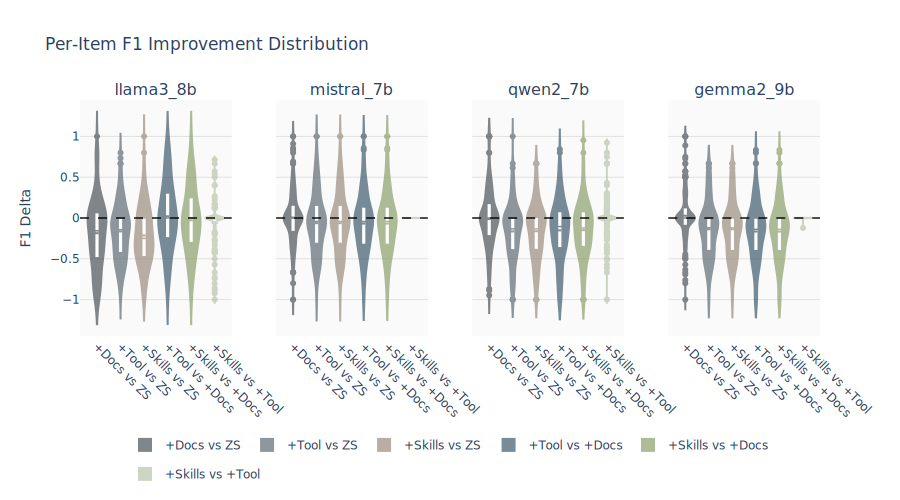

,model,comparison,mean_delta,% improved
0,llama3_8b,+Docs vs ZS,-0.186,27.0%
1,llama3_8b,+Tool vs ZS,-0.165,24.5%
2,llama3_8b,+Skills vs ZS,-0.214,23.0%
3,llama3_8b,+Tool vs +Docs,0.021,43.5%
4,llama3_8b,+Skills vs +Docs,-0.028,37.5%
5,llama3_8b,+Skills vs +Tool,-0.050,12.5%
6,mistral_7b,+Docs vs ZS,0.005,32.0%
7,mistral_7b,+Tool vs ZS,-0.063,32.5%
8,mistral_7b,+Skills vs ZS,-0.063,32.5%
9,mistral_7b,+Tool vs +Docs,-0.068,34.5%


In [15]:
# Paired Delta Plot (violin plots) - Faceted by Model

deltas = []
for model in models:
    model_data = df_results[df_results["model"] == model]
    pivot = model_data.pivot(index="sample_id", columns="condition", values="f1")

    comparisons = [
        ("with_docs", "zero_shot", "+Docs vs ZS"),
        ("with_tools", "zero_shot", "+Tool vs ZS"),
        ("with_skills", "zero_shot", "+Skills vs ZS"),
        ("with_tools", "with_docs", "+Tool vs +Docs"),
        ("with_skills", "with_docs", "+Skills vs +Docs"),
        ("with_skills", "with_tools", "+Skills vs +Tool"),
    ]

    for cond1, cond2, label in comparisons:
        if cond1 in pivot.columns and cond2 in pivot.columns:
            delta = pivot[cond1] - pivot[cond2]
            for d in delta.dropna():
                deltas.append({"model": model, "comparison": label, "delta": d})

df_deltas = pd.DataFrame(deltas)

if len(df_deltas) > 0:
    comparison_labels = [
        c for c in COMPARISON_ORDER if c in df_deltas["comparison"].values
    ]

    fig = make_subplots(
        rows=1,
        cols=len(models),
        subplot_titles=models,
        shared_yaxes=True,
        horizontal_spacing=0.06,
    )

    for i, model in enumerate(models):
        model_deltas = df_deltas[df_deltas["model"] == model]

        for comp in comparison_labels:
            subset = model_deltas[model_deltas["comparison"] == comp]

            if len(subset) > 0:
                fig.add_trace(
                    go.Violin(
                        x=[comp] * len(subset),
                        y=subset["delta"],
                        name=comp,
                        legendgroup=comp,
                        scalemode="width",
                        width=0.8,
                        line_color=COMPARISON_COLORS[comp],
                        fillcolor=COMPARISON_COLORS[comp],
                        opacity=0.7,
                        meanline_visible=True,
                        box_visible=True,
                        box_fillcolor="white",
                        box_line=dict(color=COMPARISON_COLORS[comp], width=1.5),
                        showlegend=(i == 0),
                    ),
                    row=1,
                    col=i + 1,
                )

    # Add zero reference line to each subplot
    for i in range(len(models)):
        fig.add_hline(
            y=0, line_dash="dash", line_color="black", opacity=0.7, row=1, col=i + 1
        )

    fig.update_layout(
        title="Per-Item F1 Improvement Distribution",
        plot_bgcolor="#fafafa",
        legend=dict(orientation="h", yanchor="top", y=-0.40, xanchor="center", x=0.5),
        margin=dict(b=160),
        height=500,
        width=900,
        violinmode="group",
    )

    for col in range(1, len(models) + 1):
        fig.update_yaxes(
            title_text="F1 Delta" if col == 1 else None,
            gridcolor="#e0e0e0",
            row=1,
            col=col,
        )
    fig.update_xaxes(tickangle=45)

    fig.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))

    # Summary stats by model as DataFrame
    delta_rows = []
    for model in models:
        model_deltas = df_deltas[df_deltas["model"] == model]
        for comp in comparison_labels:
            subset = model_deltas[model_deltas["comparison"] == comp]["delta"]
            if len(subset) > 0:
                pct_positive = (subset > 0).mean() * 100
                delta_rows.append(
                    {
                        "model": model,
                        "comparison": comp,
                        "mean_delta": subset.mean(),
                        "% improved": pct_positive,
                    }
                )
    delta_summary = pd.DataFrame(delta_rows)
    display(
        delta_summary.style.format(
            {"mean_delta": "{:.3f}", "% improved": "{:.1f}%"}
        ).set_caption(
            "Delta Summary by Model: mean F1 change and % of samples that improved"
        )
    )
else:
    print("Not enough data for paired delta analysis")

**Delta summary:** The table and printout above show paired F1 deltas by comparison (zero_shot → +Docs, +Docs → +Tool, +Tool → +Skills). Mean delta and percent of samples that improved are reported per model; use these to see where documentation or tool use helps or hurts relative to the previous condition.

#### Statistical significance: paired t-tests and effect size

Within-sample design: each sample appears in all four conditions. This cell runs **paired t-tests** (F1 per condition vs F1 zero-shot at the sample level) and **Cohen's d** for key comparisons (tools vs zero-shot, skills vs tools). Use the printed table in the paper to report p-values and effect sizes; the notebook is run-agnostic (pilot or main).

In [ ]:
# Paired t-tests (condition vs zero_shot) and Cohen's d for key comparisons
from scipy import stats


def cohens_d(x, y):
    """Paired Cohen's d: (mean(x)-mean(y)) / pooled_std of differences."""
    d = x - y
    n = len(d.dropna())
    if n < 2:
        return float("nan")
    std_d = d.std()
    if std_d is None or std_d == 0 or not np.isfinite(std_d):
        return 0.0 if (x.mean() - y.mean()) == 0 else float("nan")
    return (x.mean() - y.mean()) / std_d


results_stats = []
for model in models:
    model_data = df_results[df_results["model"] == model]
    pivot = model_data.pivot(index="sample_id", columns="condition", values="f1")
    if "zero_shot" not in pivot.columns:
        continue
    zs = pivot["zero_shot"]
    for cond in conditions:
        if cond == "zero_shot":
            continue
        if cond not in pivot.columns:
            continue
        other = pivot[cond]
        valid = zs.notna() & other.notna()
        if valid.sum() < 2:
            continue
        t_stat, p_val = stats.ttest_rel(other[valid], zs[valid])
        d = cohens_d(other[valid], zs[valid])
        delta = other[valid] - zs[valid]
        pct_improved = (delta > 0).sum() / valid.sum() * 100
        results_stats.append(
            {
                "model": model,
                "condition": cond,
                "comparison": f"{cond} vs zero_shot",
                "t": t_stat,
                "p": p_val,
                "cohens_d": d,
                "n": valid.sum(),
                "mean_delta": delta.mean(),
                "pct_improved": pct_improved,
            }
        )

# Paired t-test and Cohen's d for +Tool vs +Docs and +Skills vs +Docs
for model in models:
    model_data = df_results[df_results["model"] == model]
    pivot = model_data.pivot(index="sample_id", columns="condition", values="f1")
    for c1, c2, label in [
        ("with_tools", "with_docs", "with_tools vs with_docs"),
        ("with_skills", "with_docs", "with_skills vs with_docs"),
    ]:
        if c1 in pivot.columns and c2 in pivot.columns:
            a, b = pivot[c1], pivot[c2]
            valid = a.notna() & b.notna()
            if valid.sum() >= 2:
                t_stat, p_val = stats.ttest_rel(a[valid], b[valid])
                d = cohens_d(a[valid], b[valid])
                delta = a[valid] - b[valid]
                pct_improved = (delta > 0).sum() / valid.sum() * 100
                results_stats.append(
                    {
                        "model": model,
                        "condition": label,
                        "comparison": label,
                        "t": t_stat,
                        "p": p_val,
                        "cohens_d": d,
                        "n": valid.sum(),
                        "mean_delta": delta.mean(),
                        "pct_improved": pct_improved,
                    }
                )

# Paired t-test and Cohen's d (and % improved) for skills vs tools
for model in models:
    model_data = df_results[df_results["model"] == model]
    pivot = model_data.pivot(index="sample_id", columns="condition", values="f1")
    for c1, c2, label in [("with_skills", "with_tools", "skills vs tools")]:
        if c1 in pivot.columns and c2 in pivot.columns:
            a, b = pivot[c1], pivot[c2]
            valid = a.notna() & b.notna()
            if valid.sum() >= 2:
                t_stat, p_val = stats.ttest_rel(a[valid], b[valid])
                d = cohens_d(a[valid], b[valid])
                delta = a[valid] - b[valid]
                pct_improved = (delta > 0).sum() / valid.sum() * 100
                results_stats.append(
                    {
                        "model": model,
                        "condition": label,
                        "comparison": label,
                        "t": t_stat,
                        "p": p_val,
                        "cohens_d": d,
                        "n": valid.sum(),
                        "mean_delta": delta.mean(),
                        "pct_improved": pct_improved,
                    }
                )

df_stats = pd.DataFrame(results_stats)
if len(df_stats) > 0:
    pd.set_option("display.width", 1000)
    pd.set_option("display.max_colwidth", 40)
    display(
        df_stats.style.format(
            {
                "t": "{:.3f}",
                "p": "{:.4f}",
                "cohens_d": "{:.3f}",
                "n": "{:.0f}",
                "mean_delta": "{:.3f}",
                "pct_improved": "{:.1f}%",
            },
            na_rep="—",
        ).set_caption(
            "Paired t-tests and Cohen's d for all pairwise comparisons; mean_delta and % improved computed in this block."
        )
    )
else:
    print("Not enough data for paired tests.")

,model,condition,comparison,t,p,cohens_d,n,mean_delta,pct_improved
0,llama3_8b,with_docs,with_docs vs zero_shot,-6.110,0.0000,-0.432,200,-0.186,27.0%
1,llama3_8b,with_tools,with_tools vs zero_shot,-6.622,0.0000,-0.468,200,-0.165,24.5%
2,llama3_8b,with_skills,with_skills vs zero_shot,-8.255,0.0000,-0.584,200,-0.214,23.0%
3,mistral_7b,with_docs,with_docs vs zero_shot,0.233,0.8161,0.016,200,0.005,32.0%
4,mistral_7b,with_tools,with_tools vs zero_shot,-2.375,0.0185,-0.168,200,-0.063,32.5%
5,mistral_7b,with_skills,with_skills vs zero_shot,-2.375,0.0185,-0.168,200,-0.063,32.5%
6,qwen2_7b,with_docs,with_docs vs zero_shot,-0.521,0.6030,-0.037,200,-0.013,35.0%
7,qwen2_7b,with_tools,with_tools vs zero_shot,-6.612,0.0000,-0.468,200,-0.164,23.5%
8,qwen2_7b,with_skills,with_skills vs zero_shot,-6.554,0.0000,-0.463,200,-0.162,25.5%
9,gemma2_9b,with_docs,with_docs vs zero_shot,1.272,0.2050,0.090,200,0.028,32.0%


#### Degradation heatmap: Delta (condition minus zero-shot) by model and condition

A colored grid of mean F1 change relative to zero-shot (positive = improvement, negative = degradation). Useful to see at a glance which model-condition cells gain or lose; the notebook is run-agnostic.

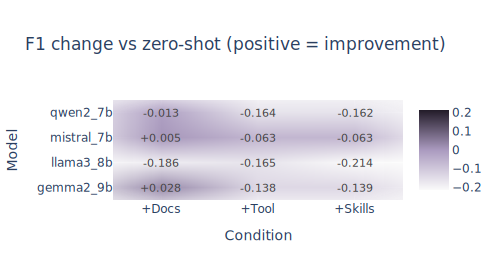

In [17]:
# Degradation heatmap: delta = mean F1(condition) - mean F1(zero_shot) per (model, condition)
agg = df_results.groupby(["model", "condition"])["f1"].mean().unstack(fill_value=0)
agg = agg.reindex(columns=conditions, fill_value=0)
if "zero_shot" in agg.columns:
    delta = agg.subtract(agg["zero_shot"], axis=0)
    delta = delta.drop(columns=["zero_shot"], errors="ignore")
    delta.columns = [CONDITION_LABELS.get(c, c) for c in delta.columns]
    z_min, z_max = delta.values.min(), delta.values.max()
    z_abs = max(abs(z_min), abs(z_max), 0.01)
    fig_delta = go.Figure(
        data=go.Heatmap(
            z=delta.values,
            x=delta.columns.tolist(),
            y=delta.index.tolist(),
            text=[[f"{v:+.3f}" for v in row] for row in delta.values],
            texttemplate="%{text}",
            textfont=dict(size=11),
            colorscale=[[0, "#fafafa"], [0.5, "#AA9ABF"], [1, "#221B28"]],
            zmid=0,
            zmin=-z_abs,
            zmax=z_abs,
        )
    )
    fig_delta.update_layout(
        title="F1 change vs zero-shot (positive = improvement)",
        xaxis_title="Condition",
        yaxis_title="Model",
        plot_bgcolor="#fafafa",
        height=280,
        width=500,
    )
    fig_delta.show(
        renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96))
    )
else:
    print("No zero_shot column in aggregated F1.")

#### Detection recall by PII type

The benchmark and label schema have **many** PII types (e.g. 136 in `pii_label_to_piicodex.json`); the run produces one row per (model, condition, pii_type) for every type that appears in ground truth. Plotting all types would be unreadable, so this figure shows only the **top N types by frequency in this run** (N = 6 by default): the types that appear in the most (model, condition) cells in `df_pii`. That reflects "most common in the evaluated samples," not the full schema. Full breakdown for all types is in `df_pii`; change `TOP_N_PII_TYPES` in the code cell to show more or fewer types.

In [18]:
# Performance by PII Type - Faceted by Model
# Only the top N PII types by frequency (in this run) are plotted; change to show more or fewer.
TOP_N_PII_TYPES = 10

pii_type_results = []

for r in all_results:
    gt = r["ground_truth"]
    preds = r["predictions"]

    gt_types = set(
        normalize_pii_type(item.get("type", "")) for item in gt if item.get("type")
    )

    for pii_type in gt_types:
        gt_of_type = [
            g for g in gt if normalize_pii_type(g.get("type", "")) == pii_type
        ]
        preds_of_type = [
            p for p in preds if normalize_pii_type(p.get("type", "")) == pii_type
        ]

        recall = len(preds_of_type) / len(gt_of_type) if gt_of_type else 0
        recall = min(recall, 1.0)

        pii_type_results.append(
            {
                "model": r["model"],
                "condition": r["condition"],
                "pii_type": pii_type,
                "recall": recall,
            }
        )

df_pii = pd.DataFrame(pii_type_results)

if len(df_pii) > 0:
    top_types = (
        df_pii[df_pii["pii_type"] != "UNKNOWN"]["pii_type"]
        .value_counts()
        .head(TOP_N_PII_TYPES)
        .index.tolist()
    )

    df_pii_top = df_pii[df_pii["pii_type"].isin(top_types)]

    # Skills improvement by PII type (recall delta vs zero-shot) as DataFrame
    rows = []
    for model in models:
        model_data = df_pii_top[df_pii_top["model"] == model]
        agg = (
            model_data.groupby(["pii_type", "condition"])["recall"]
            .mean()
            .unstack(fill_value=0)
        )

        if "with_skills" in agg.columns and "zero_shot" in agg.columns:
            improvement = agg["with_skills"] - agg["zero_shot"]
            for pii_type in improvement.index:
                rows.append(
                    {
                        "model": model,
                        "pii_type": pii_type,
                        "recall_delta": improvement[pii_type],
                    }
                )
    if rows:
        df_skills_improvement = (
            pd.DataFrame(rows)
            .sort_values(["model", "recall_delta"], ascending=[True, False])
            .reset_index(drop=True)
        )
        display(df_skills_improvement)

        # Pivot: PII types as rows, models as columns (easier to compare across models)
        row_order = (
            df_skills_improvement.groupby("pii_type")["recall_delta"]
            .mean()
            .sort_values(ascending=False)
            .index
        )

        df_skills_improvement_pivot = df_skills_improvement.pivot(
            index="pii_type", columns="model", values="recall_delta"
        ).reindex(row_order)

        display(df_skills_improvement_pivot.style.format("{:+.3f}"))
else:
    df_skills_improvement = None
    print("No PII type data available for breakdown")

,model,pii_type,recall_delta
0,gemma2_9b,US_DRIVERS_LICENSE_NUMBER,0.622288
1,gemma2_9b,DATE,0.586957
2,gemma2_9b,US_SOCIAL_SECURITY_NUMBER,0.314565
3,gemma2_9b,ADDRESS,0.175000
4,gemma2_9b,EMAIL_ADDRESS,0.000000
5,gemma2_9b,LOCATION,-0.132667
6,gemma2_9b,PHONE_NUMBER,-0.139706
7,gemma2_9b,DATE_TIME,-0.170635
8,gemma2_9b,PERSON,-0.215048
9,gemma2_9b,ZIPCODE,-0.269231


model,gemma2_9b,llama3_8b,mistral_7b,qwen2_7b
pii_type,,,,
US_DRIVERS_LICENSE_NUMBER,+0.622,+0.608,+0.653,+0.605
DATE,+0.587,+0.174,+0.554,+0.239
US_SOCIAL_SECURITY_NUMBER,+0.315,+0.207,+0.133,+0.414
ADDRESS,+0.175,-0.125,+0.100,+0.050
EMAIL_ADDRESS,+0.000,+0.053,+0.105,-0.026
PHONE_NUMBER,-0.140,-0.086,-0.169,-0.321
PERSON,-0.215,-0.314,-0.095,-0.199
DATE_TIME,-0.171,-0.478,-0.164,-0.256
LOCATION,-0.133,-0.383,-0.178,-0.520


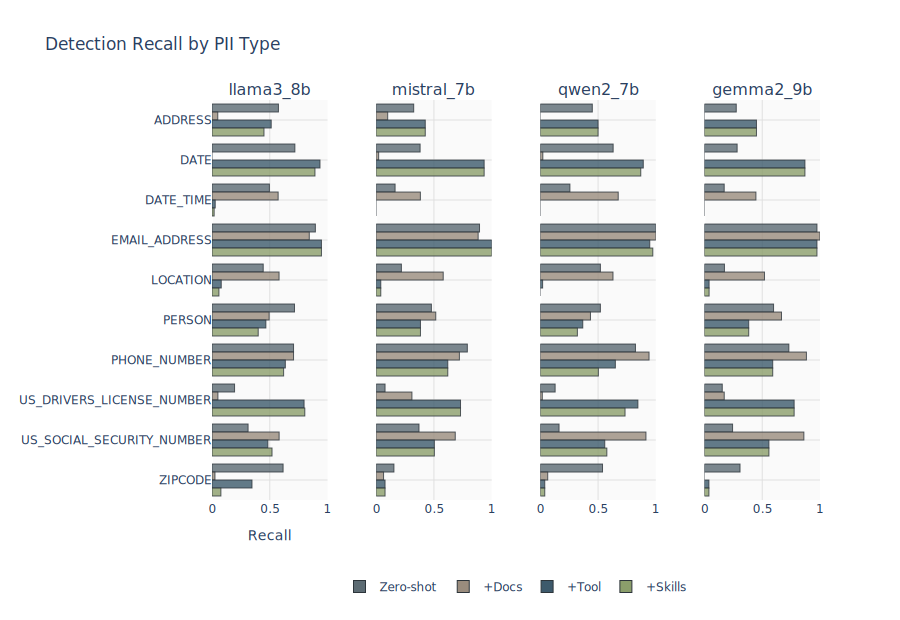

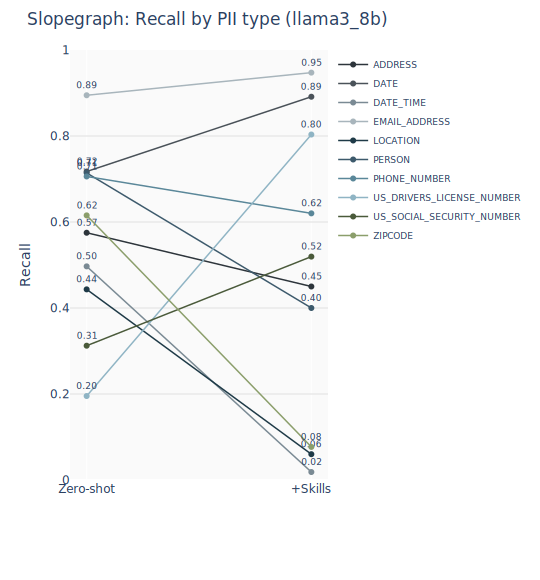

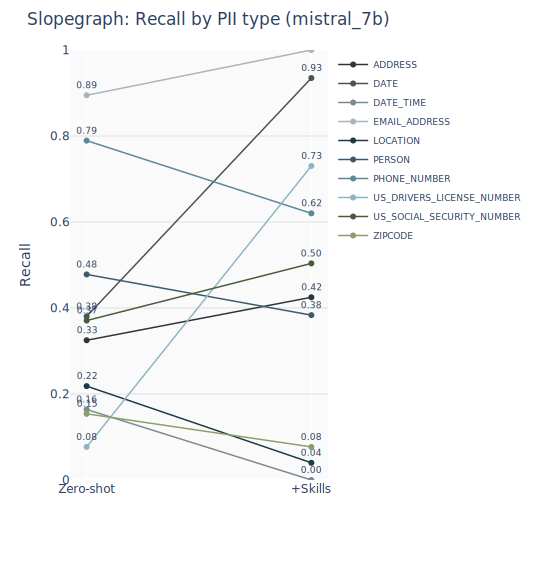

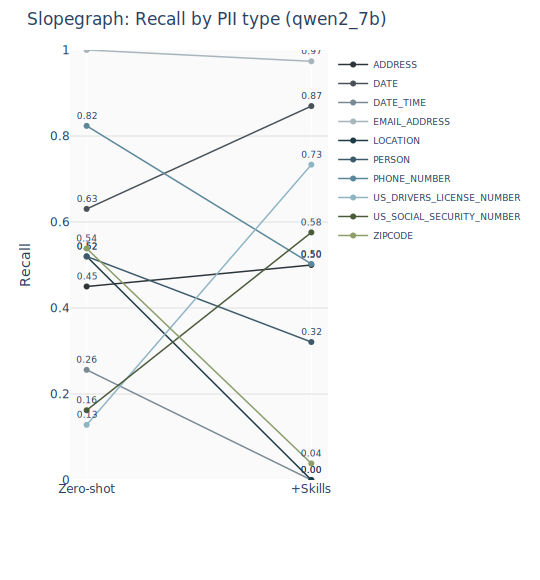

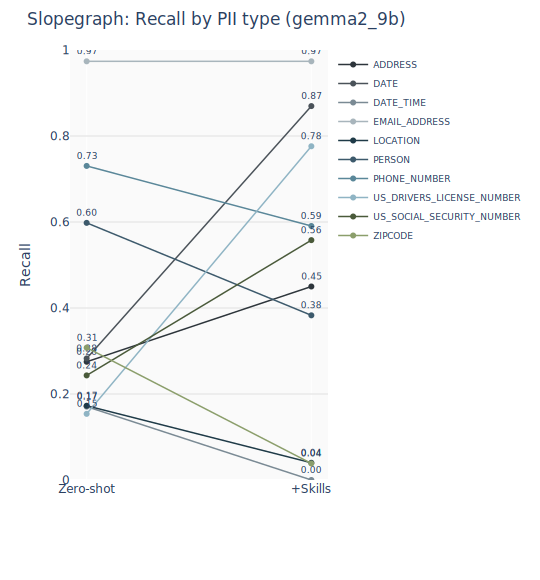

In [19]:
# Detection Recall by PII Type (horizontal bar chart)
if len(df_pii) > 0 and "df_pii_top" in dir():
    fig_alt = make_subplots(
        rows=1,
        cols=len(models),
        subplot_titles=models,
        shared_yaxes=True,
        horizontal_spacing=0.08,
    )
    for i, model in enumerate(models):
        model_data = df_pii_top[df_pii_top["model"] == model]
        agg = (
            model_data.groupby(["pii_type", "condition"])["recall"]
            .mean()
            .unstack(fill_value=0)
        )
        agg = agg.reindex(columns=conditions, fill_value=0)
        pii_types = agg.index.tolist()
        for cond in conditions:
            if cond in agg.columns:
                fig_alt.add_trace(
                    go.Bar(
                        name=CONDITION_LABELS[cond],
                        x=agg[cond],
                        y=pii_types,
                        orientation="h",
                        marker_color=CONDITION_COLORS[cond],
                        marker_line=dict(width=1, color="#2D353B"),
                        marker_opacity=0.8,
                        showlegend=(i == 0),
                        legendgroup=cond,
                    ),
                    row=1,
                    col=i + 1,
                )
    fig_alt.update_layout(
        title="Detection Recall by PII Type",
        plot_bgcolor="#fafafa",
        barmode="group",
        legend=dict(orientation="h", yanchor="top", y=-0.18, xanchor="center", x=0.5),
        margin=dict(b=120),
        height=400 + 22 * len(pii_types),
        width=900,
    )
    for col in range(1, len(models) + 1):
        fig_alt.update_xaxes(
            range=[0, 1],
            gridcolor="#e0e0e0",
            title_text="Recall" if col == 1 else None,
            row=1,
            col=col,
        )
        fig_alt.update_yaxes(autorange="reversed", gridcolor="#e0e0e0", row=1, col=col)
    fig_alt.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))

    # Slopegraph: zero-shot vs with_skills recall per PII type
    left_cond, right_cond = "zero_shot", "with_skills"
    if left_cond in conditions and right_cond in conditions:
        for model in models:
            model_data = df_pii_top[df_pii_top["model"] == model]
            agg = (
                model_data.groupby(["pii_type", "condition"])["recall"]
                .mean()
                .unstack(fill_value=0)
            )
            pii_types = agg.index.tolist()
            fig_slope = go.Figure()
            for j, pii_type in enumerate(pii_types):
                y_left = agg.loc[pii_type, left_cond] if left_cond in agg.columns else 0
                y_right = (
                    agg.loc[pii_type, right_cond] if right_cond in agg.columns else 0
                )
                fig_slope.add_trace(
                    go.Scatter(
                        x=[CONDITION_LABELS[left_cond], CONDITION_LABELS[right_cond]],
                        y=[y_left, y_right],
                        mode="lines+markers+text",
                        line=dict(
                            width=1.5, color=EXTENDED_COLORS[j % len(EXTENDED_COLORS)]
                        ),
                        marker=dict(
                            size=6, color=EXTENDED_COLORS[j % len(EXTENDED_COLORS)]
                        ),
                        text=[f"{y_left:.2f}", f"{y_right:.2f}"],
                        textposition="top center",
                        textfont=dict(size=9),
                        name=pii_type,
                    )
                )
            fig_slope.update_layout(
                title=f"Slopegraph: Recall by PII type ({model})",
                plot_bgcolor="#fafafa",
                margin=dict(l=70, r=180, b=100, t=50),
                height=400 + 18 * len(pii_types),
                width=540,
                legend=dict(
                    orientation="v",
                    yanchor="top",
                    y=1,
                    xanchor="left",
                    x=1.02,
                    font=dict(size=9),
                ),
            )
            fig_slope.update_yaxes(
                range=[0, 1], gridcolor="#e0e0e0", title_text="Recall"
            )
            fig_slope.update_xaxes(tickangle=0)
            fig_slope.show(
                renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96))
            )
else:
    print("Run the above cell first to build df_pii and df_pii_top.")

<em>Note: The above only shows for top 10 PII detected. For additional PII types, expand beyond the 10.</em>

#### Execution Reliability

Error rates and prediction counts by configuration. Doc viewed % and Tool executed % use data added to the run upload; if you load results from before that change, both default to 0 until you re-run and re-upload.

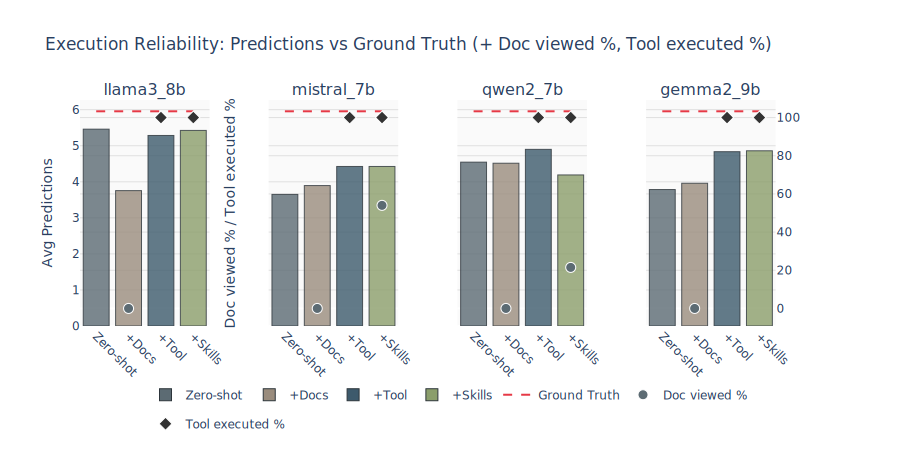

,Zero-shot (err %),Zero-shot (avg preds),+Docs (err %),+Docs (avg preds),+Tool (err %),+Tool (avg preds),+Skills (err %),+Skills (avg preds),GT (avg)
model,,,,,,,,,
gemma2_9b,0.0,3.8,0.0,4.0,0.0,4.8,0.0,4.9,6.0
llama3_8b,0.0,5.5,0.0,3.8,0.0,5.3,0.0,5.4,6.0
mistral_7b,0.0,3.6,0.0,3.9,0.0,4.4,0.0,4.4,6.0
qwen2_7b,0.0,4.5,0.0,4.5,0.0,4.9,0.0,4.2,6.0


In [20]:
# Execution Reliability - Faceted by Model

reliability_data = []

for r in all_results:
    reliability_data.append(
        {
            "model": r["model"],
            "condition": r["condition"],
            "has_error": r["error"] is not None,
            "n_predictions": len(r["predictions"]),
            "n_ground_truth": len(r["ground_truth"]),
            "skill_viewed": r.get("skill_viewed", False),
            "tool_executed": r.get("tool_executed", False),
        }
    )

df_rel = pd.DataFrame(reliability_data)

fig = make_subplots(
    rows=1,
    cols=len(models),
    subplot_titles=models,
    shared_yaxes=True,
    horizontal_spacing=0.08,
    specs=[[{"secondary_y": True} for _ in models]],
)

for i, model in enumerate(models):
    model_data = df_rel[df_rel["model"] == model]

    pred_counts = model_data.groupby("condition")["n_predictions"].mean()
    error_rates = model_data.groupby("condition")["has_error"].mean() * 100
    doc_viewed_pct = model_data.groupby("condition")["skill_viewed"].mean() * 100
    tool_executed_pct = model_data.groupby("condition")["tool_executed"].mean() * 100
    gt_mean = model_data["n_ground_truth"].mean()

    for cond in conditions:
        pred_val = pred_counts.get(cond, 0)
        err_val = error_rates.get(cond, 0)

        # Bars for prediction counts (opacity for visibility with lines)
        fig.add_trace(
            go.Bar(
                name=CONDITION_LABELS[cond],
                x=[CONDITION_LABELS[cond]],
                y=[pred_val],
                marker_color=CONDITION_COLORS[cond],
                marker_line=dict(width=1, color="#2D353B"),
                marker_opacity=0.8,
                text=[f"{err_val:.0f}%" if err_val > 0 else ""],
                textposition="outside",
                showlegend=(i == 0),
                legendgroup=cond,
            ),
            row=1,
            col=i + 1,
            secondary_y=False,
        )

    # Ground truth baseline
    fig.add_trace(
        go.Scatter(
            name="Ground Truth",
            x=[CONDITION_LABELS[c] for c in conditions],
            y=[gt_mean] * len(conditions),
            mode="lines",
            line=dict(color="#E63946", width=2, dash="dash"),
            showlegend=(i == 0),
            legendgroup="gt",
        ),
        row=1,
        col=i + 1,
        secondary_y=False,
    )

    # Doc viewed % only where docs exist (+Docs, +Skills); markers only
    conditions_with_docs = ["with_docs", "with_skills"]
    doc_x = [CONDITION_LABELS[c] for c in conditions_with_docs]
    doc_vals = [doc_viewed_pct.get(c, 0) for c in conditions_with_docs]
    fig.add_trace(
        go.Scatter(
            name="Doc viewed %",
            x=doc_x,
            y=doc_vals,
            mode="markers",
            marker=dict(size=10, color="#5C6B73", line=dict(width=1, color="white")),
            showlegend=(i == 0),
            legendgroup="doc_viewed",
        ),
        row=1,
        col=i + 1,
        secondary_y=True,
    )

    # Tool executed % only where tools exist (+Tool, +Skills); diamond to match
    conditions_with_tools = ["with_tools", "with_skills"]
    tool_x = [CONDITION_LABELS[c] for c in conditions_with_tools]
    tool_vals = [tool_executed_pct.get(c, 0) for c in conditions_with_tools]
    fig.add_trace(
        go.Scatter(
            name="Tool executed %",
            x=tool_x,
            y=tool_vals,
            mode="markers",
            marker=dict(
                size=10,
                symbol="diamond",
                color="#333",
                line=dict(width=1, color="white"),
            ),
            showlegend=(i == 0),
            legendgroup="tool_executed",
        ),
        row=1,
        col=i + 1,
        secondary_y=True,
    )

fig.update_layout(
    title="Execution Reliability: Predictions vs Ground Truth (+ Doc viewed %, Tool executed %)",
    plot_bgcolor="#fafafa",
    barmode="group",
    legend=dict(orientation="h", yanchor="top", y=-0.24, xanchor="center", x=0.5),
    margin=dict(b=120),
    height=450,
    width=900,
)

for col in range(1, len(models) + 1):
    fig.update_yaxes(gridcolor="#e0e0e0", row=1, col=col, secondary_y=False)
    fig.update_yaxes(gridcolor="#e0e0e0", row=1, col=col, secondary_y=True)
fig.update_yaxes(title_text="Avg Predictions", row=1, col=1, secondary_y=False)
fig.update_yaxes(
    title_text="Doc viewed % / Tool executed %", secondary_y=True, row=1, col=1
)
fig.update_xaxes(tickangle=45)

fig.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))

# Summary by model (DataFrame)
rel_summary = (
    df_rel.groupby(["model", "condition"])
    .agg(
        err_pct=("has_error", lambda s: s.mean() * 100),
        avg_preds=("n_predictions", "mean"),
    )
    .reset_index()
)
gt_per_model = df_rel.groupby("model")["n_ground_truth"].mean()
rel_summary["GT"] = rel_summary["model"].map(gt_per_model)
pivot_err = rel_summary.pivot(index="model", columns="condition", values="err_pct")
pivot_preds = rel_summary.pivot(index="model", columns="condition", values="avg_preds")
pivot_err.columns = [CONDITION_LABELS[c] + " (err %)" for c in pivot_err.columns]
pivot_preds.columns = [
    CONDITION_LABELS[c] + " (avg preds)" for c in pivot_preds.columns
]
reliability_table = pd.concat([pivot_err, pivot_preds], axis=1)
col_order = []
for c in conditions:
    col_order.append(CONDITION_LABELS[c] + " (err %)")
    col_order.append(CONDITION_LABELS[c] + " (avg preds)")
reliability_table = reliability_table[
    [x for x in col_order if x in reliability_table.columns]
]
reliability_table.insert(reliability_table.shape[1], "GT (avg)", gt_per_model)
display(
    reliability_table.style.format("{:.1f}").set_caption("Reliability Summary by Model")
)

#### Skill-viewed vs not-viewed (with_skills only)

For the with_skills condition, some runs record whether the model actually viewed the skill document. This cell compares mean F1 when the skill was viewed vs when it was not (per model). All models are shown; where a model has 100% or 0% view rate, the other group appears as n=0. Run-agnostic.

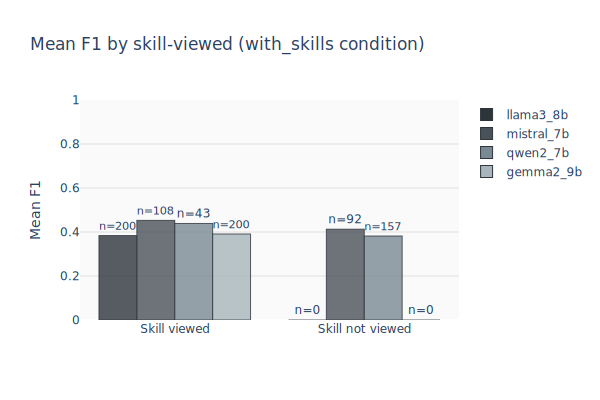

In [21]:
# Skill-viewed vs not-viewed F1 (with_skills only)
df_skills = df_results[df_results["condition"] == "with_skills"].copy()
if "skill_viewed" in df_skills.columns:
    # Include all models so the chart is not confusing (missing models = 100% or 0% viewed)
    rows = []
    for model in models:
        g = df_skills[df_skills["model"] == model]
        for sv, label in [(True, "Skill viewed"), (False, "Skill not viewed")]:
            subset = g[g["skill_viewed"] == sv]
            mean_f1 = subset["f1"].mean() if len(subset) >= 1 else 0.0
            rows.append(
                {
                    "model": model,
                    "group": label,
                    "mean_f1": mean_f1,
                    "n": len(subset),
                }
            )
    df_sv = pd.DataFrame(rows)
    fig_sv = go.Figure()
    for model in models:
        sub = df_sv[df_sv["model"] == model]
        model_color = EXTENDED_COLORS[models.index(model) % len(EXTENDED_COLORS)]
        fig_sv.add_trace(
            go.Bar(
                x=sub["group"],
                y=sub["mean_f1"],
                name=model,
                marker_color=model_color,
                marker_line=dict(width=1, color="#2D353B"),
                marker_opacity=0.8,
                text=[f"n={int(r['n'])}" for _, r in sub.iterrows()],
                textposition="outside",
            )
        )
    fig_sv.update_layout(
        title="Mean F1 by skill-viewed (with_skills condition)",
        barmode="group",
        yaxis_title="Mean F1",
        yaxis=dict(range=[0, 1], gridcolor="#e0e0e0"),
        plot_bgcolor="#fafafa",
        height=400,
        width=600,
    )
    fig_sv.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))
else:
    print("skill_viewed not in results; skip skill-viewed analysis.")

#### Turn count and elapsed time vs F1

Correlation of per-sample conversation turns and elapsed time with F1 (per model and condition). Indicates whether more turns or longer runs tend to yield higher or lower F1. Run-agnostic.

In [22]:
# Turn count and elapsed time vs F1 (per sample)
def _safe_corr(x: np.ndarray, y: np.ndarray) -> float:
    """Pearson r; return nan if either series has zero variance or n < 2 (avoids RuntimeWarning)."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    if len(x) < 2 or len(y) < 2:
        return float("nan")
    if np.std(x) == 0 or np.std(y) == 0:
        return float("nan")
    with np.errstate(invalid="ignore", divide="ignore"):
        r = np.corrcoef(x, y)[0, 1]
    return float(r) if np.isfinite(r) else float("nan")


has_turns = "conversation_turns" in df_results.columns
has_elapsed = "elapsed_seconds" in df_results.columns
if has_turns or has_elapsed:
    corr_rows = []
    for (model, condition), g in df_results.groupby(["model", "condition"]):
        if has_turns and g["conversation_turns"].notna().any() and len(g) >= 2:
            r_t = _safe_corr(
                g["f1"].fillna(0).values, g["conversation_turns"].fillna(1).values
            )
            corr_rows.append(
                {"model": model, "condition": condition, "metric": "turns", "r": r_t}
            )
        if has_elapsed and g["elapsed_seconds"].notna().any() and len(g) >= 2:
            r_e = _safe_corr(
                g["f1"].fillna(0).values, g["elapsed_seconds"].fillna(0).values
            )
            corr_rows.append(
                {
                    "model": model,
                    "condition": condition,
                    "metric": "elapsed_s",
                    "r": r_e,
                }
            )
    if corr_rows:
        df_corr = pd.DataFrame(corr_rows)
        df_corr["condition_metric"] = (
            df_corr["condition"] + " (" + df_corr["metric"] + ")"
        )
        corr_pivot = df_corr.pivot(
            index="model", columns="condition_metric", values="r"
        )
        cond_order = sorted(df_corr["condition"].unique().tolist())
        metric_order = ["turns", "elapsed_s"]
        col_order = [c + " (" + m + ")" for c in cond_order for m in metric_order]
        corr_pivot = corr_pivot.reindex(
            columns=[c for c in col_order if c in corr_pivot.columns]
        )
        display(
            corr_pivot.style.format("{:.3f}", na_rep="n/a").set_caption(
                "Correlation with F1 (per sample, by model and condition)"
            )
        )
    else:
        print("No turn or elapsed data for correlation.")
else:
    print(
        "conversation_turns and elapsed_seconds not in df_results; skip correlations."
    )

condition_metric,with_docs (turns),with_docs (elapsed_s),with_skills (turns),with_skills (elapsed_s),with_tools (turns),with_tools (elapsed_s),zero_shot (turns),zero_shot (elapsed_s)
model,,,,,,,,
gemma2_9b,n/a,0.051,n/a,0.191,n/a,0.180,n/a,0.187
llama3_8b,n/a,0.084,-0.179,-0.053,n/a,-0.092,n/a,-0.018
mistral_7b,n/a,0.116,0.033,0.065,n/a,0.110,n/a,-0.004
qwen2_7b,n/a,0.083,0.071,0.140,0.002,0.103,n/a,0.164


### 4.3 Confidence Interval Analysis

Check if sample size is sufficient for reliable conclusions. If CI is too wide, consider increasing N.

In [23]:
import numpy as np
from scipy import stats


def compute_confidence_interval(data: pd.Series, confidence: float = 0.95) -> tuple:
    """Compute confidence interval for mean."""
    n = len(data)
    if n < 2:
        return (data.mean(), data.mean(), 0.0)

    mean = data.mean()
    se = stats.sem(data)
    # Avoid scipy warning and NaN when std=0 or data has NaN
    if se <= 0 or np.isnan(se) or not np.isfinite(se):
        return (float(mean), float(mean), 0.0)
    ci = stats.t.interval(confidence, df=n - 1, loc=mean, scale=se)
    margin = (ci[1] - ci[0]) / 2
    return (ci[0], ci[1], margin)


def analyze_sample_size(df: pd.DataFrame, target_margin: float = 0.05) -> pd.DataFrame:
    """Analyze if sample size is sufficient for each condition."""
    results = []

    for (model, condition), group in df.groupby(["model", "condition"]):
        ci_low, ci_high, margin = compute_confidence_interval(group["f1"])
        mean_f1 = group["f1"].mean()
        std_f1 = group["f1"].std()
        n = len(group)

        # Is CI narrow enough?
        sufficient = margin <= target_margin

        # Minimum N required for target margin: n_req = (t * std / margin)^2 (t for consistency with CI)
        if std_f1 > 0 and np.isfinite(std_f1):
            t_crit = stats.t.ppf(
                0.975, df=n - 1
            )  # 95% CI, same as compute_confidence_interval
            computed = int(np.ceil((t_crit * std_f1 / target_margin) ** 2))
            if sufficient:
                required_n = computed  # minimum needed; can be < n when you have more than enough
            else:
                required_n = max(
                    n + 1, computed
                )  # when insufficient, recommend strictly > n
        else:
            required_n = n  # no variance (e.g. zero_shot all zeros), keep current n

        results.append(
            {
                "model": model,
                "condition": condition,
                "n": n,
                "mean_f1": round(mean_f1, 4),
                "std_f1": round(std_f1, 4),
                "ci_low": round(ci_low, 4),
                "ci_high": round(ci_high, 4),
                "margin": round(margin, 4),
                "sufficient": sufficient,
                "required_n": required_n,
            }
        )

    return pd.DataFrame(results)


# Analyze confidence intervals
TARGET_MARGIN = 0.05  # Target: +/- 5% margin on F1
ci_analysis = analyze_sample_size(df_results, TARGET_MARGIN)

all_sufficient = ci_analysis["sufficient"].all()
summary = (
    "Sample size SUFFICIENT for all conditions."
    if all_sufficient
    else f"Sample size INSUFFICIENT for some; consider N={ci_analysis[~ci_analysis['sufficient']]['required_n'].max()}."
)
display(
    ci_analysis.style.format(
        {
            "mean_f1": "{:.4f}",
            "std_f1": "{:.4f}",
            "ci_low": "{:.4f}",
            "ci_high": "{:.4f}",
            "margin": "{:.4f}",
        }
    ).set_caption(
        f"Confidence Interval Analysis (target margin: +/-{TARGET_MARGIN}). {summary}"
    )
)

,model,condition,n,mean_f1,std_f1,ci_low,ci_high,margin,sufficient,required_n
0,gemma2_9b,with_docs,200,0.5573,0.2914,0.5167,0.5980,0.0406,True,133
1,gemma2_9b,with_skills,200,0.3909,0.2566,0.3551,0.4267,0.0358,True,103
2,gemma2_9b,with_tools,200,0.3915,0.2571,0.3557,0.4273,0.0358,True,103
3,gemma2_9b,zero_shot,200,0.5295,0.3154,0.4856,0.5735,0.0440,True,155
4,llama3_8b,with_docs,200,0.4121,0.3295,0.3661,0.4580,0.0459,True,169
5,llama3_8b,with_skills,200,0.3838,0.2611,0.3474,0.4202,0.0364,True,107
6,llama3_8b,with_tools,200,0.4334,0.2699,0.3957,0.4710,0.0376,True,114
7,llama3_8b,zero_shot,200,0.5980,0.3179,0.5537,0.6423,0.0443,True,158
8,mistral_7b,with_docs,200,0.5029,0.3036,0.4605,0.5452,0.0423,True,144
9,mistral_7b,with_skills,200,0.4344,0.2717,0.3965,0.4723,0.0379,True,115


### 4.4 Efficiency, Condition Profiles, and PII Detection plots

Interactive plots for tool calls, timing, and metrics. Run the cells below after `df_results` and (for heatmap) `df_pii` are defined.

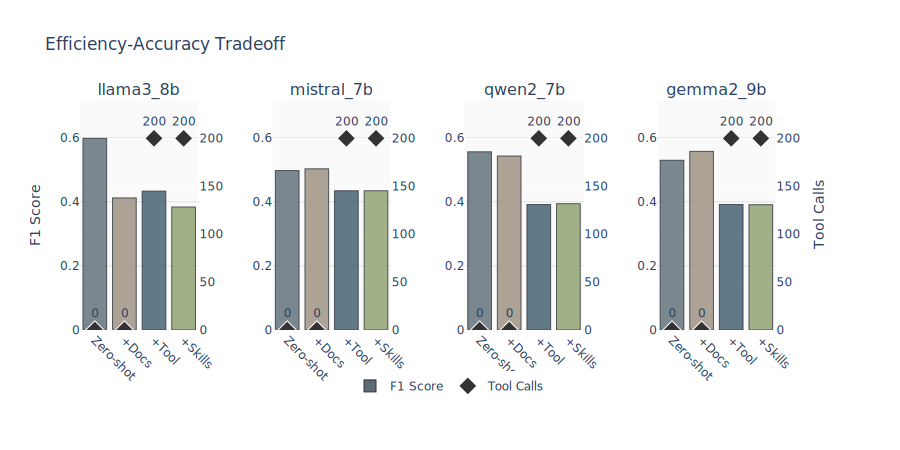

,model,condition,F1,tool_calls,efficiency
0,llama3_8b,Zero-shot,0.598,0,0.0000
1,llama3_8b,+Docs,0.412,0,0.0000
2,llama3_8b,+Tool,0.433,200,0.0022
3,llama3_8b,+Skills,0.384,200,0.0019
4,mistral_7b,Zero-shot,0.497,0,0.0000
5,mistral_7b,+Docs,0.503,0,0.0000
6,mistral_7b,+Tool,0.434,200,0.0022
7,mistral_7b,+Skills,0.434,200,0.0022
8,qwen2_7b,Zero-shot,0.556,0,0.0000
9,qwen2_7b,+Docs,0.543,0,0.0000


In [24]:
# Efficiency-Accuracy Tradeoff - Faceted by Model
# Efficiency = F1 per tool call; +Docs = docs only; +Skills = docs + tool use (discovery).

fig = make_subplots(
    rows=1,
    cols=len(models),
    subplot_titles=models,
    specs=[[{"secondary_y": True} for _ in models]],
    horizontal_spacing=0.1,
)

# Get global max for consistent y-axes (avoid degenerate [0,0] when all tool_calls=0)
all_f1 = df_results.groupby(["model", "condition"])["f1"].mean()
all_tools = df_results.groupby(["model", "condition"])["tool_calls"].sum()
max_f1 = all_f1.max() * 1.2
max_tools = max(all_tools.max() * 1.2, 1)

for i, model in enumerate(models):
    model_data = df_results[df_results["model"] == model]

    summary = (
        model_data.groupby("condition")
        .agg({"f1": "mean", "tool_calls": "sum", "time_elapsed": "mean"})
        .reindex(conditions)
    )

    # Bars for F1
    fig.add_trace(
        go.Bar(
            name="F1 Score",
            x=[CONDITION_LABELS[cond] for cond in conditions],
            y=summary["f1"],
            marker_color=[CONDITION_COLORS[cond] for cond in conditions],
            marker_line=dict(width=1, color="#2D353B"),
            marker_opacity=0.8,
            showlegend=(i == 0),
            legendgroup="f1",
        ),
        row=1,
        col=i + 1,
        secondary_y=False,
    )

    # Diamonds for tool calls
    fig.add_trace(
        go.Scatter(
            name="Tool Calls",
            x=[CONDITION_LABELS[cond] for cond in conditions],
            y=summary["tool_calls"],
            mode="markers+text",
            marker=dict(
                size=14,
                symbol="diamond",
                color="#333",
                line=dict(width=1, color="white"),
            ),
            text=[f"{int(t)}" for t in summary["tool_calls"]],
            textposition="top center",
            showlegend=(i == 0),
            legendgroup="tools",
        ),
        row=1,
        col=i + 1,
        secondary_y=True,
    )

fig.update_layout(
    title="Efficiency-Accuracy Tradeoff",
    plot_bgcolor="#fafafa",
    legend=dict(orientation="h", yanchor="top", y=-0.18, xanchor="center", x=0.5),
    margin=dict(b=120),
    height=450,
    width=900,
)

for i in range(len(models)):
    fig.update_yaxes(
        range=[0, max_f1], gridcolor="#e0e0e0", row=1, col=i + 1, secondary_y=False
    )
    fig.update_yaxes(range=[0, max_tools], row=1, col=i + 1, secondary_y=True)

fig.update_yaxes(title_text="F1 Score", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="Tool Calls", row=1, col=len(models), secondary_y=True)
fig.update_xaxes(tickangle=45)

fig.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))

# Efficiency summary as DataFrame
eff_rows = []
for model in models:
    model_data = df_results[df_results["model"] == model]
    for cond in conditions:
        cond_data = model_data[model_data["condition"] == cond]
        f1 = cond_data["f1"].mean()
        tools = int(cond_data["tool_calls"].sum())
        efficiency = f1 / tools if tools > 0 else 0.0
        eff_rows.append(
            {
                "model": model,
                "condition": CONDITION_LABELS[cond],
                "F1": f1,
                "tool_calls": tools,
                "efficiency": efficiency,
            }
        )
eff_summary = pd.DataFrame(eff_rows)
display(
    eff_summary.style.format({"F1": "{:.3f}", "efficiency": "{:.4f}"}).set_caption(
        "Efficiency Summary by Model (efficiency = F1 / tool_calls)"
    )
)

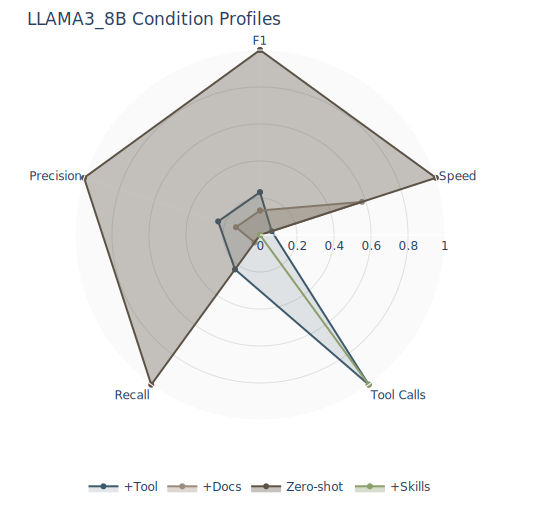

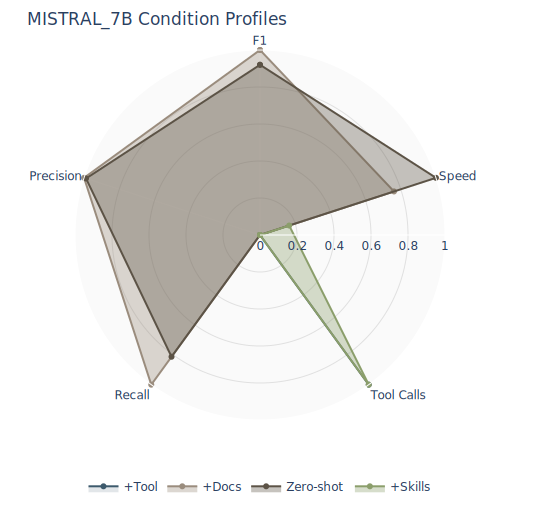

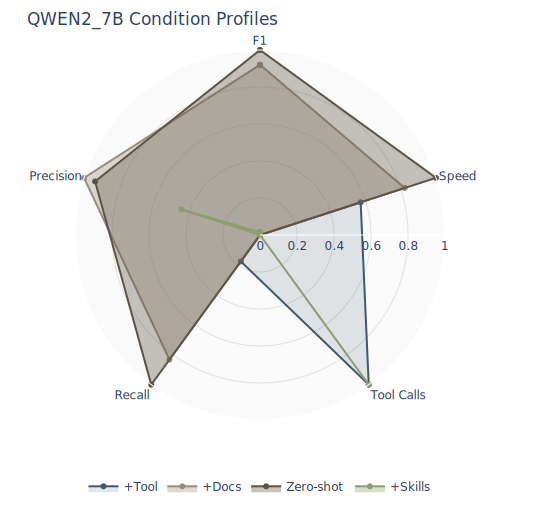

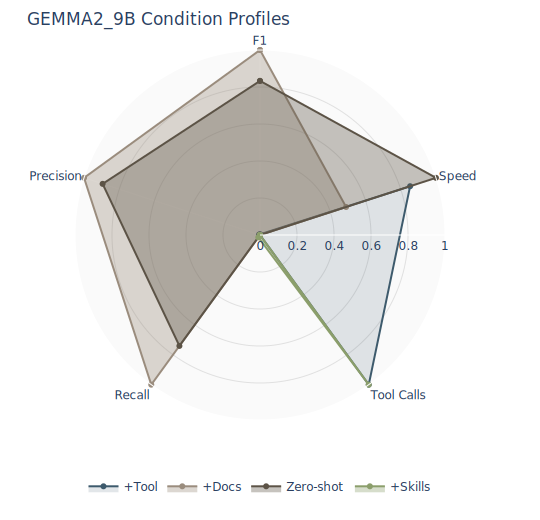

In [25]:
# Condition Profiles (spider) - one chart per model
# Model x condition profiles: normalized F1, precision, recall, tool_calls, speed (higher = better).

categories = ["f1", "precision", "recall", "tool_calls", "time_elapsed"]
category_labels = ["F1", "Precision", "Recall", "Tool Calls", "Speed"]
trace_order = [
    "with_tools",
    "with_docs",
    "zero_shot",
    "with_skills",
]  # skills last = on top
# Distinct color for zero_shot (avoids confusion with with_tools teal)
radar_colors = {**CONDITION_COLORS, "zero_shot": "#5c5346"}


def _hex_to_rgba(hex_str, alpha=0.25):
    h = hex_str.lstrip("#")
    return f"rgba({int(h[0:2], 16)}, {int(h[2:4], 16)}, {int(h[4:6], 16)}, {alpha})"


for model in models:
    model_data = df_results[df_results["model"] == model]

    # Aggregate by condition
    radar_agg = (
        model_data.groupby("condition")
        .agg(
            {
                "f1": "mean",
                "precision": "mean",
                "recall": "mean",
                "tool_calls": "mean",
                "time_elapsed": "mean",
            }
        )
        .reset_index()
    )

    # Normalize each dimension to 0-1
    for col in categories:
        lo, hi = radar_agg[col].min(), radar_agg[col].max()
        if hi > lo:
            radar_agg[col] = (radar_agg[col] - lo) / (hi - lo)
        else:
            radar_agg[col] = 0.5

    # Invert time_elapsed so higher = faster
    radar_agg["time_elapsed"] = 1 - radar_agg["time_elapsed"]

    fig = go.Figure()
    for cond in trace_order:
        cond_rows = radar_agg[radar_agg["condition"] == cond]
        if len(cond_rows) == 0:
            continue
        row = cond_rows.iloc[0]
        color = radar_colors[cond]
        alpha = 0.15 if cond == "with_tools" else 0.35

        fig.add_trace(
            go.Scatterpolar(
                r=row[categories].tolist() + [row[categories[0]]],
                theta=category_labels + [category_labels[0]],
                name=CONDITION_LABELS[cond],
                fill="toself",
                line=dict(color=color, width=2),
                fillcolor=_hex_to_rgba(color, alpha),
            )
        )

    fig.update_layout(
        title=f"{model.upper()} Condition Profiles",
        polar=dict(
            radialaxis=dict(range=[0, 1], gridcolor="#e0e0e0"),
            angularaxis=dict(rotation=90),
            bgcolor="#fafafa",
        ),
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.14,
            xanchor="center",
            x=0.5,
        ),
        margin=dict(l=70, r=90, b=100, t=50),
        height=520,
        width=540,
    )

    fig.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))

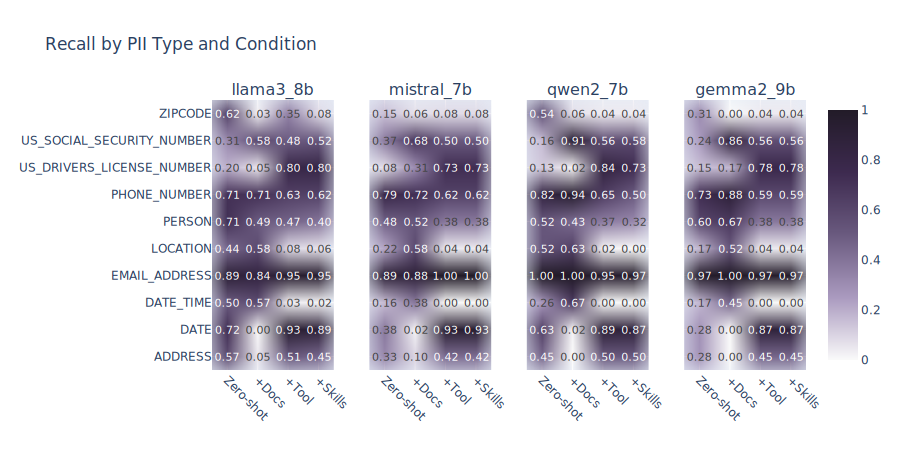

In [26]:
# Heatmap - PII Type x Condition - Faceted by Model
TOP_N_PII_TYPES_HEATMAP = 10

if len(df_pii) > 0:
    top_types = (
        df_pii[df_pii["pii_type"] != "UNKNOWN"]["pii_type"]
        .value_counts()
        .head(TOP_N_PII_TYPES_HEATMAP)
        .index.tolist()
    )
    df_heat = df_pii[df_pii["pii_type"].isin(top_types)]

    heatmap_scale = [
        [0, "#fafafa"],
        [0.25, "#AA9ABF"],
        [0.5, "#6A5A7F"],
        [0.75, "#3D2A4F"],
        [1, "#221B28"],
    ]

    fig = make_subplots(
        rows=1, cols=len(models), subplot_titles=models, horizontal_spacing=0.06
    )

    for i, model in enumerate(models):
        model_data = df_heat[df_heat["model"] == model]
        pivot_recall = model_data.pivot_table(
            index="pii_type", columns="condition", values="recall", aggfunc="mean"
        )

        # Reorder columns
        pivot_recall = pivot_recall.reindex(columns=conditions, fill_value=0)
        pivot_recall.columns = [CONDITION_LABELS.get(c, c) for c in conditions]

        fig.add_trace(
            go.Heatmap(
                z=pivot_recall.values,
                x=pivot_recall.columns.tolist(),
                y=pivot_recall.index.tolist(),
                text=[[f"{v:.2f}" for v in row] for row in pivot_recall.values],
                texttemplate="%{text}",
                colorscale=heatmap_scale,
                showscale=(i == len(models) - 1),  # Only show colorbar on last
                zmin=0,
                zmax=1,
            ),
            row=1,
            col=i + 1,
        )

    fig.update_layout(title="Recall by PII Type and Condition", height=450, width=900)

    fig.update_xaxes(tickangle=45)
    # Only show y-axis (PII type) labels on the left-most heatmap to avoid overlap
    for col in range(2, len(models) + 1):
        fig.update_yaxes(showticklabels=False, row=1, col=col)

    fig.show(renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96)))


else:
    print("Run cells above first to build df_pii for this heatmap.")

#### Per-PII-type radar chart (one chart per model)

Recall by PII type for each model across conditions; one radar chart is printed per model. Run the cells above first to build `df_pii`. Uses the same top-N PII types.

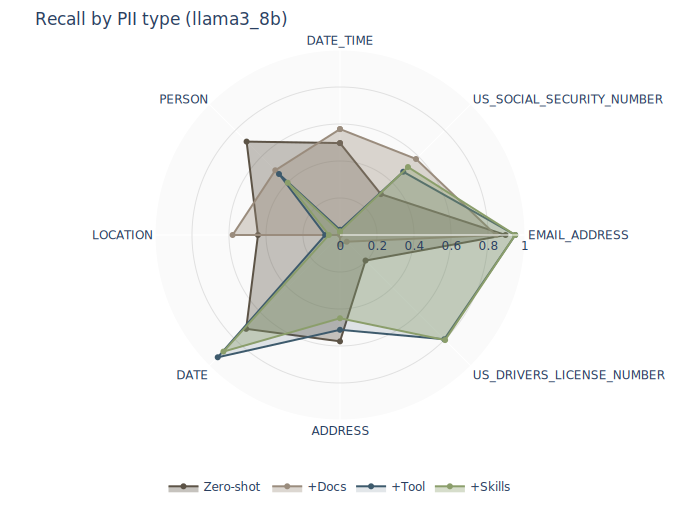

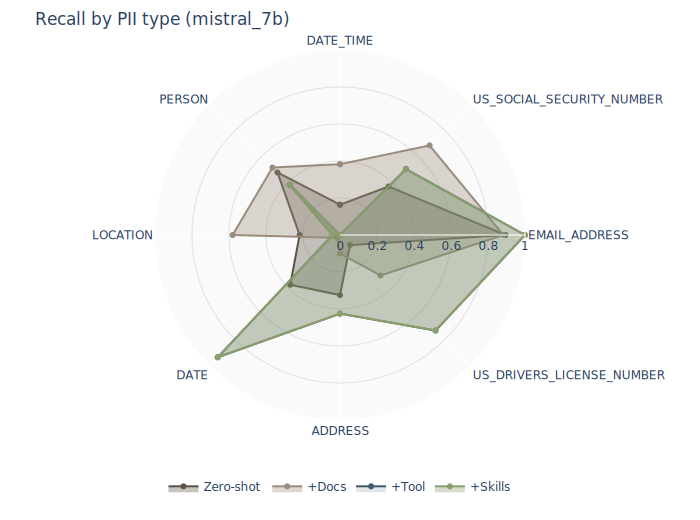

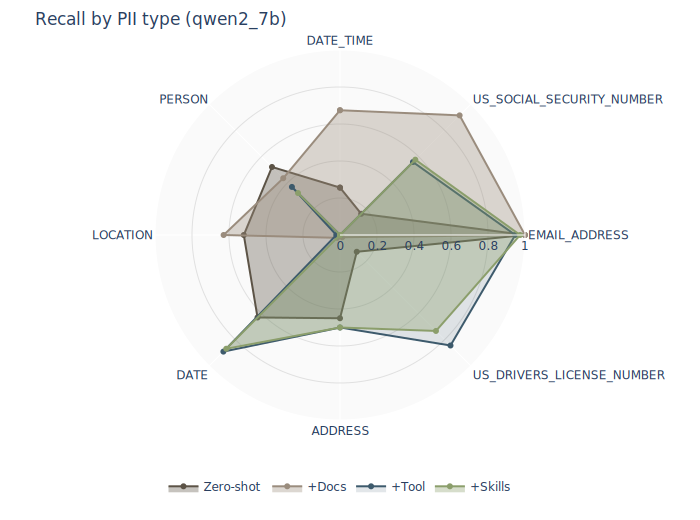

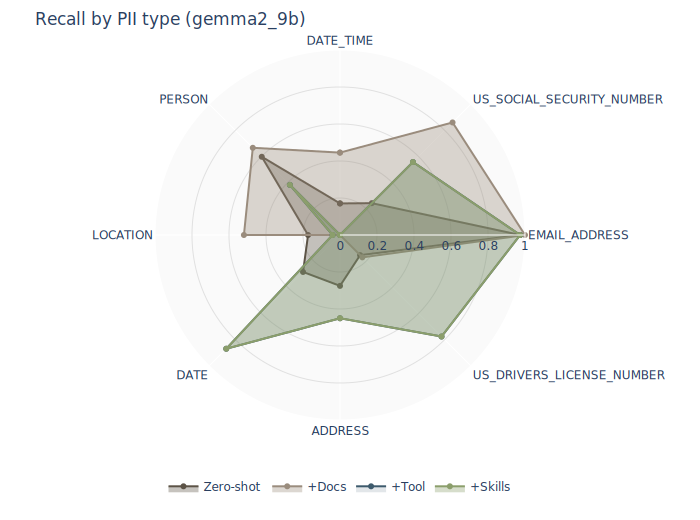

In [27]:
# Per-PII-type radar chart - one chart per model
if "df_pii" in dir() and len(df_pii) > 0:
    TOP_N_RADAR = 8
    top_types = (
        df_pii[df_pii["pii_type"] != "UNKNOWN"]["pii_type"]
        .value_counts()
        .head(TOP_N_RADAR)
        .index.tolist()
    )
    df_radar = df_pii[df_pii["pii_type"].isin(top_types)]
    radar_colors = {**CONDITION_COLORS, "zero_shot": "#5c5346"}

    def _hex_to_rgba(hex_str, alpha=0.25):
        h = hex_str.lstrip("#")
        return f"rgba({int(h[0:2], 16)}, {int(h[2:4], 16)}, {int(h[4:6], 16)}, {alpha})"

    for model in models:
        model_radar = df_radar[df_radar["model"] == model]
        pivot_radar = (
            model_radar.pivot_table(
                index="pii_type", columns="condition", values="recall", aggfunc="mean"
            )
            .reindex(columns=conditions, fill_value=0)
            .fillna(0)
        )
        pivot_radar = pivot_radar.reindex(top_types, fill_value=0)
        theta = pivot_radar.index.tolist() + [pivot_radar.index[0]]

        fig_radar = go.Figure()
        for cond in conditions:
            if cond in pivot_radar.columns:
                r_vals = pivot_radar[cond].tolist() + [pivot_radar[cond].iloc[0]]
                color = radar_colors[cond]
                alpha = 0.15 if cond == "with_tools" else 0.35
                fig_radar.add_trace(
                    go.Scatterpolar(
                        r=r_vals,
                        theta=theta,
                        name=CONDITION_LABELS[cond],
                        fill="toself",
                        line=dict(color=color, width=2),
                        fillcolor=_hex_to_rgba(color, alpha),
                    )
                )

        fig_radar.update_layout(
            title=f"Recall by PII type ({model})",
            polar=dict(
                radialaxis=dict(range=[0, 1], gridcolor="#e0e0e0"),
                angularaxis=dict(rotation=90),
                bgcolor="#fafafa",
            ),
            legend=dict(
                orientation="h",
                yanchor="top",
                y=-0.14,
                xanchor="center",
                x=0.5,
            ),
            margin=dict(l=70, r=90, b=100, t=50),
            height=520,
            width=700,
        )
        fig_radar.show(
            renderer="svg", config=dict(toImageButtonOptions=dict(scale=300 / 96))
        )
else:
    print("Run the above cells first to build df_pii for the radar chart.")

## 5. Save & Upload

Results are saved to a separate repo (`pii-skills-ablation-results`) to keep ground truth and predictions cleanly separated.

In [28]:
# Build results dataset (separate from benchmark)
SELECTED_MODELS = sorted(set(r["model"] for r in all_results))
model_str = "_".join(SELECTED_MODELS)

# Full schema to match Hub: scores/error string; include tool_executed, skill_viewed, elapsed_seconds, conversation_turns
results_records = []
for r in all_results:
    scores_val = r.get("scores")
    scores_str = json.dumps(scores_val) if scores_val is not None else "[]"
    results_records.append(
        {
            "sample_id": r["sample_id"],
            "source": r.get("source", ""),
            "model": r["model"],
            "condition": r["condition"],
            "prompt_version": prompt_version,
            "run_type": RUN_TYPE,
            "predictions": json.dumps(r.get("predictions") or []),
            "scores": scores_str,
            "error": r.get("error"),
            "tool_executed": bool(r.get("tool_executed", False)),
            "skill_viewed": bool(r.get("skill_viewed", False)),
            "elapsed_seconds": r.get("elapsed_seconds"),
            "conversation_turns": r.get("conversation_turns"),
        }
    )

from datasets import Features, Value
hub_features = Features({
    "sample_id": Value("string"),
    "source": Value("string"),
    "model": Value("string"),
    "condition": Value("string"),
    "prompt_version": Value("string"),
    "run_type": Value("string"),
    "predictions": Value("string"),
    "scores": Value("string"),
    "error": Value("null"),
    "tool_executed": Value("bool"),
    "skill_viewed": Value("bool"),
    "elapsed_seconds": Value("float64"),
    "conversation_turns": Value("int64"),
})
results_dataset = Dataset.from_list(results_records, features=hub_features)
print(f"Results dataset: {len(results_dataset)} rows (run_type={RUN_TYPE})")
print(f"Columns: {results_dataset.column_names}")

# Save locally under run_type subdir so pilot and main do not overwrite each other
results_dir = REPO_ROOT / "results" / RUN_TYPE
results_dir.mkdir(parents=True, exist_ok=True)

model_str = "_".join(SELECTED_MODELS)
local_path = results_dir / f"results_{model_str}.json"
with open(local_path, "w") as f:
    json.dump(results_records, f, indent=2)
print(f"Saved locally: {local_path}")

Results dataset: 3200 rows (run_type=pilot)
Columns: ['sample_id', 'source', 'model', 'condition', 'prompt_version', 'run_type', 'predictions', 'scores', 'error', 'tool_executed', 'skill_viewed', 'elapsed_seconds', 'conversation_turns']
Saved locally: /Users/erosado/work/pii-codex-skills-ablation-study/results/pilot/results_gemma2_9b_llama3_8b_mistral_7b_qwen2_7b.json


In [29]:
# Upload results to HuggingFace results repo (split = run_type + prompt_version)
# Pilot and main stay on separate splits: pilot_v1, main_v1, etc.
split_name = f"{RUN_TYPE}_{prompt_version}"
results_dataset.push_to_hub(
    RESULTS_REPO,
    split=split_name,
    private=True,
    commit_message=f"Add {RUN_TYPE} results from {model_str} (prompts {prompt_version})",
)

print(
    f"\nResults uploaded to: https://huggingface.co/datasets/{RESULTS_REPO} (split={split_name})"
)
print(f"Benchmark (ground truth) at: https://huggingface.co/datasets/{BENCHMARK_REPO}")
print("Experiment complete!")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


Results uploaded to: https://huggingface.co/datasets/EdyVision/pii-skills-ablation-results (split=pilot_v1)
Benchmark (ground truth) at: https://huggingface.co/datasets/EdyVision/pii-skills-ablation
Experiment complete!
